In [28]:
# ==========================================
# 0. 导包
# ==========================================
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

from lifelines import WeibullFitter, CoxTimeVaryingFitter

import matplotlib.pyplot as plt

In [29]:
# ==========================================
# 1. 读文件（FD001-FD004 train）
# ==========================================
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'SM{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# 读取所有四个数据集 (FD001-FD004)
file_paths = [
    'CMAPSSData/train_FD001.txt',
    'CMAPSSData/train_FD002.txt',
    'CMAPSSData/train_FD003.txt',
    'CMAPSSData/train_FD004.txt'
]

df_list = []
unit_offset = 0  # 用于给不同数据集的引擎编号加偏移，避免ID冲突

for i, file_path in enumerate(file_paths):
    df_temp = pd.read_csv(file_path, sep=r'\s+', header=None, names=col_names)
    # 给unit_nr加上偏移量，避免不同数据集的引擎ID冲突
    df_temp['unit_nr'] = df_temp['unit_nr'] + unit_offset
    df_temp['dataset'] = f'FD00{i+1}'  # 标记数据来源
    unit_offset = df_temp['unit_nr'].max()  # 更新偏移量
    df_list.append(df_temp)
    print(f"成功读取文件: {file_path}, 行数: {len(df_temp)}")

# 合并所有数据集
df = pd.concat(df_list, ignore_index=True)
print(f"\n合并完成！总数据行数: {len(df)}, 总引擎数: {df['unit_nr'].nunique()}")
print(df.head())

成功读取文件: CMAPSSData/train_FD001.txt, 行数: 20631
成功读取文件: CMAPSSData/train_FD002.txt, 行数: 53759
成功读取文件: CMAPSSData/train_FD003.txt, 行数: 24720
成功读取文件: CMAPSSData/train_FD004.txt, 行数: 61249

合并完成！总数据行数: 160359, 总引擎数: 709
   unit_nr  time_cycles  setting_1  setting_2  setting_3     SM1     SM2  \
0        1            1    -0.0007    -0.0004      100.0  518.67  641.82   
1        1            2     0.0019    -0.0003      100.0  518.67  642.15   
2        1            3    -0.0043     0.0003      100.0  518.67  642.35   
3        1            4     0.0007     0.0000      100.0  518.67  642.35   
4        1            5    -0.0019    -0.0002      100.0  518.67  642.37   

       SM3      SM4    SM5  ...     SM13     SM14    SM15  SM16  SM17  SM18  \
0  1589.70  1400.60  14.62  ...  2388.02  8138.62  8.4195  0.03   392  2388   
1  1591.82  1403.14  14.62  ...  2388.07  8131.49  8.4318  0.03   392  2388   
2  1587.99  1404.20  14.62  ...  2388.03  8133.23  8.4178  0.03   390  2388   
3  1582.79  

In [30]:
# ==========================================
# 2. 选择论文 14 个传感器
# ==========================================
selected_features = [
    'SM2','SM3','SM4','SM7','SM8','SM9','SM11',
    'SM12','SM13','SM14','SM15','SM17','SM20','SM21'
]

df_process = df[index_names + selected_features].copy()

In [31]:
# ==========================================
# 3. Min-Max 归一化（全训练集口径）
# ==========================================
scaler = MinMaxScaler()
df_process[selected_features] = scaler.fit_transform(df_process[selected_features])

print("MinMax done.")

MinMax done.


In [33]:
# ==========================================
# 4. 构建 lifelines CoxTimeVaryingFitter 所需长表
#    start=t-1, stop=t，最后一个cycle event=1
# ==========================================
df_process['start'] = df_process['time_cycles'] - 1
df_process['stop']  = df_process['time_cycles']

max_cycles = df_process.groupby('unit_nr')['time_cycles'].max()

df_process['E'] = (df_process['time_cycles'] == df_process['unit_nr'].map(max_cycles)).astype(int)

print("Long format done:",
      "rows =", len(df_process),
      "units =", df_process['unit_nr'].nunique())
print(df_process[['unit_nr','time_cycles','start','stop','E']].head())

Long format done: rows = 160359 units = 709
   unit_nr  time_cycles  start  stop  E
0        1            1      0     1  0
1        1            2      1     2  0
2        1            3      2     3  0
3        1            4      3     4  0
4        1            5      4     5  0


In [34]:
# ==========================================
# 5. 拟合 Weibull（得到 BH 参数 β, η）
#    使用每台发动机寿命 T = max_cycle，FD001 train 为 run-to-failure => E=1
# ==========================================
durations = max_cycles.values.astype(float)
events = np.ones_like(durations, dtype=int)

wb = WeibullFitter()
wb.fit(durations=durations, event_observed=events)

beta = float(wb.rho_)      # shape
eta  = float(wb.lambda_)   # scale

print("\nWeibull fitted:")
print("beta (shape) =", beta)
print("eta  (scale) =", eta)

# 计算每一行的 Baseline Hazard BH(t) = (beta/eta) * (t/eta)^(beta-1)
t = df_process['time_cycles'].astype(float).values
BH = (beta / eta) * (t / eta) ** (beta - 1.0)
df_process['BH'] = BH


Weibull fitted:
beta (shape) = 3.3643965081691114
eta  (scale) = 250.6644684311487


In [35]:
# ==========================================
# 6. 拟合 time-varying Cox（得到 HR）
#    关键：predict_partial_hazard 只喂 14 个传感器列
# ==========================================
ctv = CoxTimeVaryingFitter(penalizer=0.0)  # 若你觉得不稳定可改 1e-3 或 1e-2
ctv.fit(
    df_process[['unit_nr','start','stop','E'] + selected_features],
    id_col='unit_nr',
    start_col='start',
    stop_col='stop',
    event_col='E',
    show_progress=True
)

print("\nCox TV fitted. Top params:")
print(ctv.params_.sort_values(ascending=False))

HR = ctv.predict_partial_hazard(df_process[selected_features]).values.astype(float)
df_process['HR'] = HR

# hazard_rate（可选，后续不用于聚类）
df_process['hazard_rate'] = df_process['BH'] * df_process['HR']

Iteration 1: norm_delta = 1.06e+02, step_size = 0.9500, log_lik = -3948.97455, newton_decrement = 1.10e+03, seconds_since_start = 0.1
Iteration 2: norm_delta = 4.01e+00, step_size = 0.0950, log_lik = -2745.37331, newton_decrement = 1.75e+02, seconds_since_start = 0.3
Iteration 3: norm_delta = 4.84e+00, step_size = 0.1235, log_lik = -2713.75611, newton_decrement = 1.54e+02, seconds_since_start = 0.4
Iteration 4: norm_delta = 5.57e+00, step_size = 0.1573, log_lik = -2677.92320, newton_decrement = 1.32e+02, seconds_since_start = 0.6
Iteration 5: norm_delta = 1.54e+00, step_size = 0.0501, log_lik = -2639.67034, newton_decrement = 1.07e+02, seconds_since_start = 0.7
Iteration 6: norm_delta = 1.88e+00, step_size = 0.0638, log_lik = -2629.18649, newton_decrement = 1.01e+02, seconds_since_start = 0.9
Iteration 7: norm_delta = 2.26e+00, step_size = 0.0813, log_lik = -2616.73677, newton_decrement = 9.28e+01, seconds_since_start = 1.0
Iteration 8: norm_delta = 2.68e+00, step_size = 0.1036, log_li

In [37]:
# ==========================================
# 7. 构造聚类输入：BH + log(HR)
#    用 log(HR) 是为了抑制指数爆炸；然后做 MinMax scaling
# ==========================================
logHR = np.log(df_process['HR'].values + 1e-12)
df_process['logHR'] = logHR

# scaling（全体样本口径）
bh_scaler = MinMaxScaler()
hr_scaler = MinMaxScaler()

df_process['BH_scaled'] = bh_scaler.fit_transform(df_process[['BH']]).ravel()
df_process['logHR_scaled'] = hr_scaler.fit_transform(df_process[['logHR']]).ravel()

print("\nScaled features ready:")
print(df_process[['BH','HR','logHR','BH_scaled','logHR_scaled']].head())


Scaled features ready:
             BH        HR     logHR  BH_scaled  logHR_scaled
0  2.853697e-08  0.387155 -0.948931   0.000000      0.536872
1  1.469475e-07  0.900289 -0.105040   0.000001      0.567316
2  3.832760e-07  0.157547 -1.848034   0.000004      0.504437
3  7.566871e-07  0.107213 -2.232941   0.000009      0.490551
4  1.282478e-06  0.405154 -0.903488   0.000015      0.538511


In [38]:
# ==========================================
# 8. KMeans：分别对 BH_scaled 与 logHR_scaled 做 2 类聚类（论文结构）
#    目标：输出 BH_state ∈ {0(low),1(high)}，HR_state ∈ {0(low),1(high)}
# ==========================================
def kmeans_2class_high_is_1(x_1d, random_state=42):
    """
    对一维特征做 KMeans(2类)，并强制：均值更大的那类记为 1（高风险），更小为 0（低风险）
    """
    x_1d = np.asarray(x_1d).reshape(-1, 1)
    km = KMeans(n_clusters=2, random_state=random_state, n_init='auto')
    labels = km.fit_predict(x_1d)
    centers = km.cluster_centers_.ravel()

    high_cluster = int(np.argmax(centers))
    # 映射到 {0,1} 且 high=1
    labels_high1 = (labels == high_cluster).astype(int)
    return labels_high1, km

df_process['BH_state'], km_bh = kmeans_2class_high_is_1(df_process['BH_scaled'].values)
df_process['HR_state'], km_hr = kmeans_2class_high_is_1(df_process['logHR_scaled'].values)

print("\nKMeans centers:")
print("BH centers:", km_bh.cluster_centers_.ravel())
print("HR centers:", km_hr.cluster_centers_.ravel())

print(df_process[['BH_scaled','logHR_scaled','BH_state','HR_state']].head())


KMeans centers:
BH centers: [0.032474   0.25125047]
HR centers: [0.41451431 0.66109897]
   BH_scaled  logHR_scaled  BH_state  HR_state
0   0.000000      0.536872         0         0
1   0.000001      0.567316         0         1
2   0.000004      0.504437         0         0
3   0.000009      0.490551         0         0
4   0.000015      0.538511         0         1


In [39]:
# ==========================================
# 9. 合成 3 类健康状态（论文规则）
#    Healthy=2, Warning=1, Failure=0
# ==========================================
def combine_state(bh_state, hr_state):
    # bh_state, hr_state: 0(low) or 1(high)
    if bh_state == 0 and hr_state == 0:
        return 2  # Healthy
    if bh_state == 1 and hr_state == 1:
        return 0  # Failure
    return 1      # Warning

df_process['Health'] = [
    combine_state(bh, hr) for bh, hr in zip(df_process['BH_state'], df_process['HR_state'])
]

print("\nHealth label counts:")
print(df_process['Health'].value_counts().sort_index())


Health label counts:
Health
0    11677
1    93404
2    55278
Name: count, dtype: int64


In [40]:
# ==========================================
# 10. 强制末段 failure（论文有这一手；d 论文未明说，先用 5）
# ==========================================
d = 5
for unit in df_process['unit_nr'].unique():
    idx = (df_process[df_process['unit_nr'] == unit]
           .sort_values('time_cycles')
           .tail(d)
           .index)
    df_process.loc[idx, 'Health'] = 0

print("\nHealth label counts after tail-forcing:")
print(df_process['Health'].value_counts().sort_index())


Health label counts after tail-forcing:
Health
0    14179
1    91109
2    55071
Name: count, dtype: int64


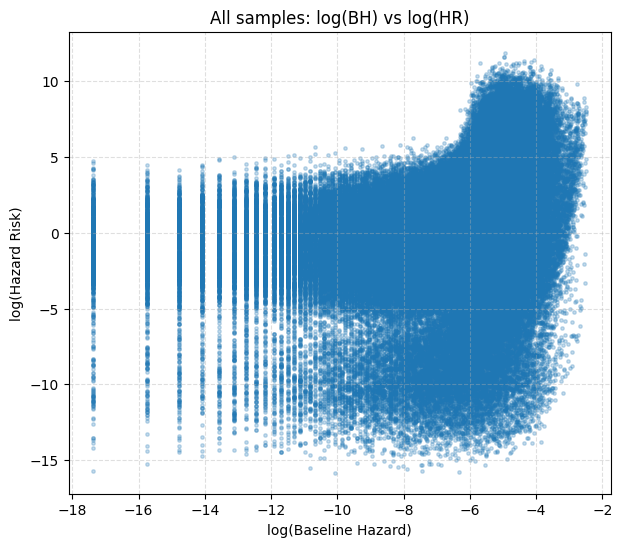

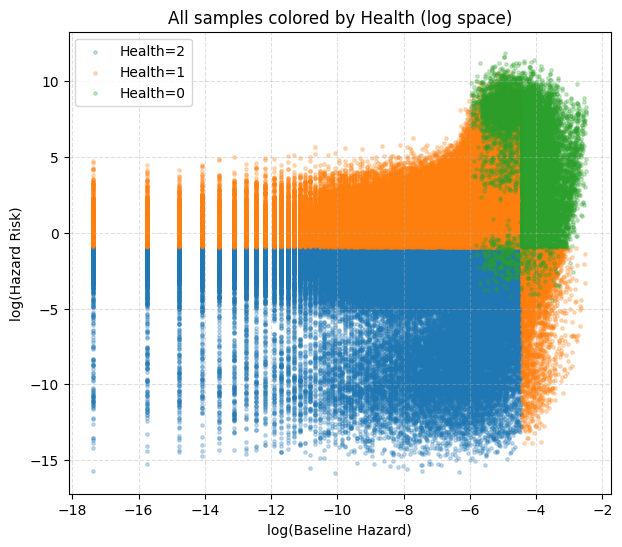

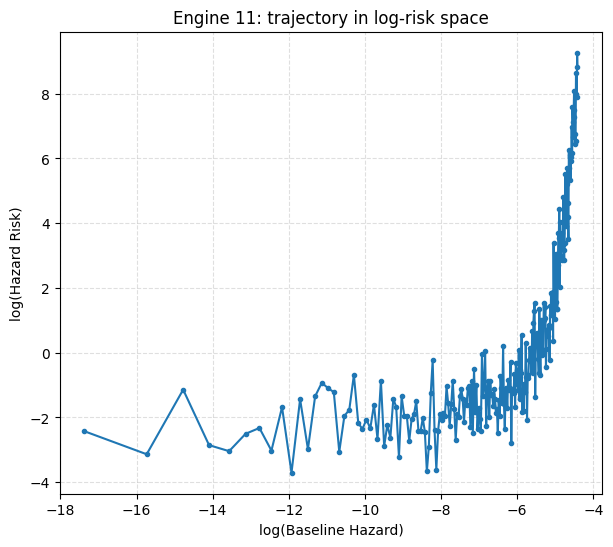

In [41]:
# ==========================================
# 11. 可视化：BH_scaled vs logHR_scaled（全体点 + 选定 engine）
# ==========================================
# 全体散点
plt.figure(figsize=(7, 6))
plt.scatter(
    np.log(df_process['BH'] + 1e-30),
    np.log(df_process['HR'] + 1e-12),
    s=6,
    alpha=0.25
)
plt.xlabel("log(Baseline Hazard)")
plt.ylabel("log(Hazard Risk)")
plt.title("All samples: log(BH) vs log(HR)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


# 按健康状态着色（颜色不指定也行，但这里为了区分更直观）
plt.figure(figsize=(7, 6))
for label in [2, 1, 0]:
    sub = df_process[df_process['Health'] == label]
    plt.scatter(
        np.log(sub['BH'] + 1e-30),
        np.log(sub['HR'] + 1e-12),
        s=6,
        alpha=0.25,
        label=f"Health={label}"
    )

plt.xlabel("log(Baseline Hazard)")
plt.ylabel("log(Hazard Risk)")
plt.title("All samples colored by Health (log space)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


# 单独看 Engine 11 的轨迹
engine_id = 11
sub11 = df_process[df_process['unit_nr'] == engine_id].sort_values('time_cycles')

plt.figure(figsize=(7, 6))
plt.plot(
    np.log(sub11['BH'] + 1e-30),
    np.log(sub11['HR'] + 1e-12),
    linewidth=1.5,
    marker='o',
    markersize=3
)

plt.xlabel("log(Baseline Hazard)")
plt.ylabel("log(Hazard Risk)")
plt.title(f"Engine {engine_id}: trajectory in log-risk space")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


In [42]:
df_process.groupby('Health')[['BH','HR']].median()


,BH,HR
Health,,
0,0.015860,91.379378
1,0.002306,5.423151
2,0.000875,0.044197


# 监督学习

In [43]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt


# 14 个传感器
selected_features = [
    'SM2','SM3','SM4','SM7','SM8','SM9','SM11',
    'SM12','SM13','SM14','SM15','SM17','SM20','SM21'
]

# 监督学习输入/标签/分组
X = df_process[selected_features].values
y = df_process['Health'].values.astype(int)
groups = df_process['unit_nr'].values  # 按发动机分组切分（关键）

print("X shape:", X.shape, "y dist:", pd.Series(y).value_counts().sort_index().to_dict())
print("n_engines:", df_process['unit_nr'].nunique())


X shape: (160359, 14) y dist: {0: 14179, 1: 91109, 2: 55071}
n_engines: 709


In [46]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
g_train, g_test = groups[train_idx], groups[test_idx]

print("train engines:", len(np.unique(g_train)), "test engines:", len(np.unique(g_test)))
print("train y dist:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("test  y dist:", pd.Series(y_test).value_counts().sort_index().to_dict())


train engines: 567 test engines: 142
train y dist: {0: 12028, 1: 71570, 2: 45721}
test  y dist: {0: 2151, 1: 19539, 2: 9350}


In [47]:
clf_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", multi_class="auto"))
])

clf_lr.fit(X_train, y_train)
pred_lr = clf_lr.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, pred_lr, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_lr))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.2703    0.7415    0.3962      2151
           1     0.9259    0.7183    0.8090     19539
           2     0.8727    0.9316    0.9012      9350

    accuracy                         0.7841     31040
   macro avg     0.6896    0.7971    0.7021     31040
weighted avg     0.8644    0.7841    0.8081     31040

Confusion matrix:
 [[ 1595   491    65]
 [ 4299 14035  1205]
 [    7   633  8710]]


In [48]:
clf_rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    max_depth=None
)

clf_rf.fit(X_train, y_train)
pred_rf = clf_rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, pred_rf, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_rf))


=== Random Forest ===
              precision    recall  f1-score   support

           0     0.6587    0.4486    0.5337      2151
           1     0.9213    0.9454    0.9332     19539
           2     0.9370    0.9543    0.9456      9350

    accuracy                         0.9137     31040
   macro avg     0.8390    0.7828    0.8042     31040
weighted avg     0.9078    0.9137    0.9092     31040

Confusion matrix:
 [[  965  1161    25]
 [  491 18473   575]
 [    9   418  8923]]


SM11    0.132047
SM13    0.100177
SM15    0.084784
SM4     0.078480
SM8     0.076703
SM2     0.074164
SM12    0.072692
SM14    0.070382
SM7     0.059850
SM9     0.053904
SM3     0.053147
SM21    0.049728
SM20    0.048666
SM17    0.045276
dtype: float64


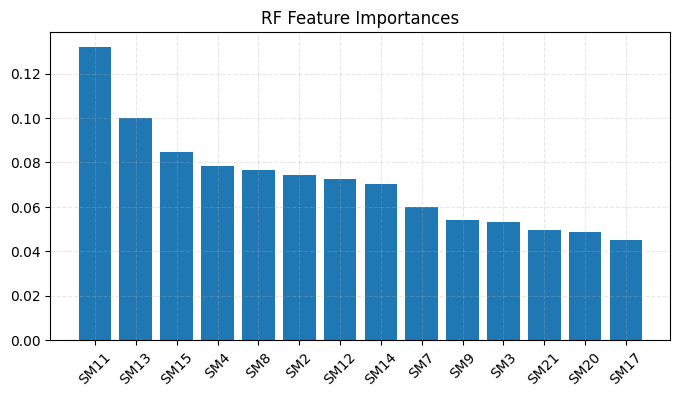

In [49]:
importances = pd.Series(clf_rf.feature_importances_, index=selected_features).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,4))
plt.bar(importances.index, importances.values)
plt.xticks(rotation=45)
plt.title("RF Feature Importances")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


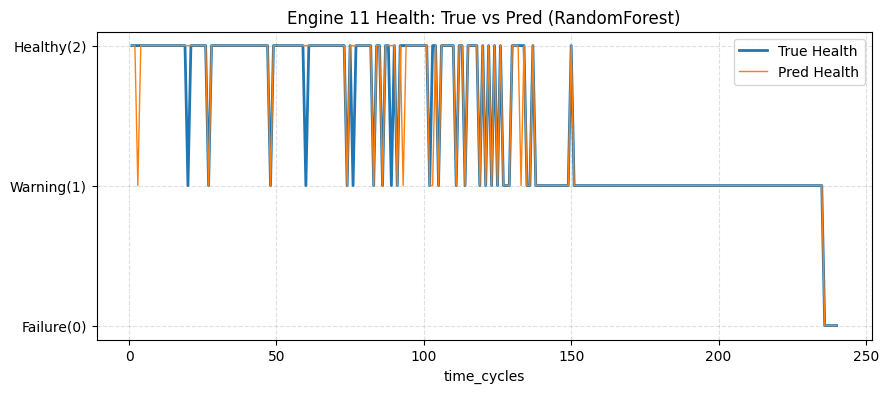

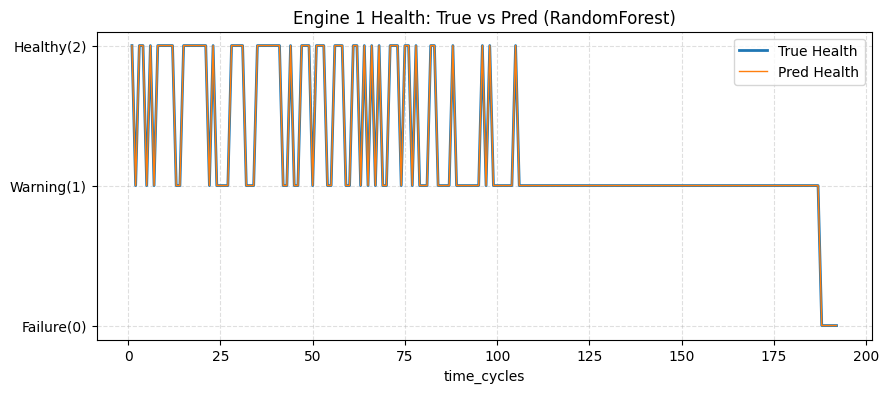

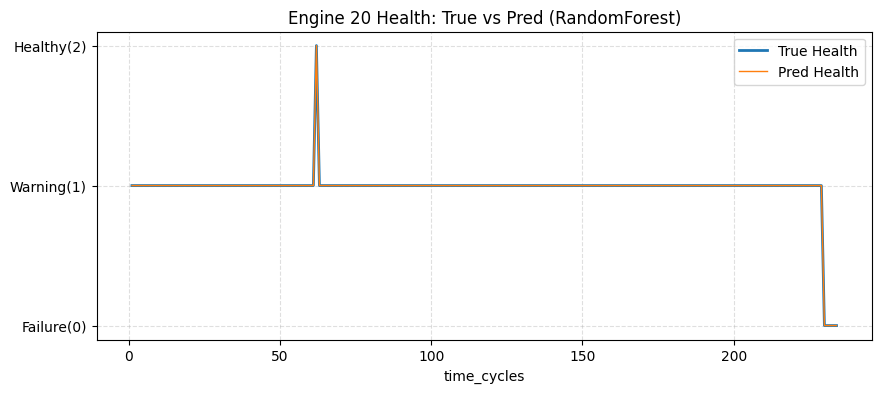

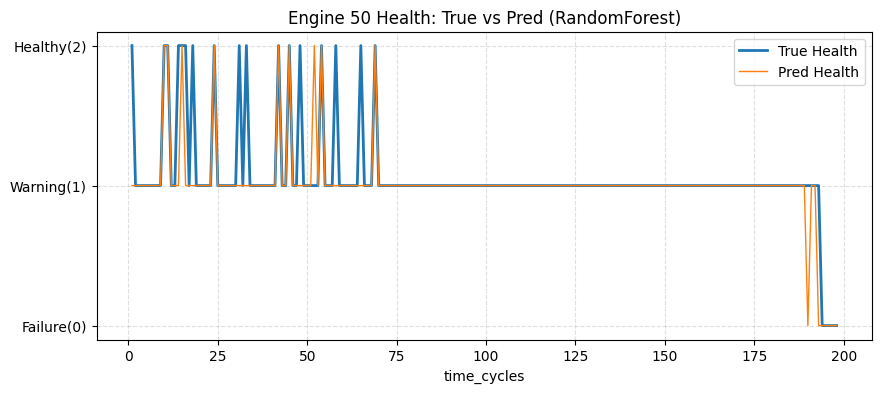

In [50]:
def plot_engine_pred(engine_id, model, title_suffix=""):
    sub = df_process[df_process["unit_nr"] == engine_id].sort_values("time_cycles")
    X_sub = sub[selected_features].values
    y_true = sub["Health"].values.astype(int)
    y_pred = model.predict(X_sub)

    plt.figure(figsize=(10,4))
    plt.plot(sub["time_cycles"], y_true, label="True Health", linewidth=2)
    plt.plot(sub["time_cycles"], y_pred, label="Pred Health", linewidth=1)
    plt.yticks([0,1,2], ["Failure(0)","Warning(1)","Healthy(2)"])
    plt.xlabel("time_cycles")
    plt.title(f"Engine {engine_id} Health: True vs Pred {title_suffix}")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.show()

# 选几个发动机看看（包含 11）
for eid in [11, 1, 20, 50]:
    plot_engine_pred(eid, clf_rf, "(RandomForest)")


In [51]:
# ======== 强制对齐论文的 state 编码 ========
# paper: 0=Healthy, 1=Warning, 2=Failure

health_map = {
    2: 0,  # Healthy -> 0
    1: 1,  # Warning -> 1
    0: 2   # Failure -> 2
}

df_process['Health_RL'] = df_process['Health'].map(health_map).astype(int)

print("Health (old) -> Health_RL (paper-aligned) counts:")
print(df_process[['Health', 'Health_RL']].value_counts().sort_index())


Health (old) -> Health_RL (paper-aligned) counts:
Health  Health_RL
0       2            14179
1       1            91109
2       0            55071
Name: count, dtype: int64


In [52]:
import numpy as np
import pandas as pd

# paper-aligned state: 0=Healthy, 1=Warning, 2=Failure
assert set(df_process["Health_RL"].unique()).issubset({0,1,2})

# 统计 n_ij：同一台发动机相邻时刻的状态转移
df_sorted = df_process.sort_values(["unit_nr", "time_cycles"]).copy()
df_sorted["next_state"] = df_sorted.groupby("unit_nr")["Health_RL"].shift(-1)

pairs = df_sorted.dropna(subset=["next_state"]).copy()
pairs["next_state"] = pairs["next_state"].astype(int)

n_ij = np.zeros((3,3), dtype=int)
for i, j in zip(pairs["Health_RL"].values.astype(int), pairs["next_state"].values.astype(int)):
    n_ij[i, j] += 1

row_sums = n_ij.sum(axis=1, keepdims=True)
P0 = np.divide(n_ij, row_sums, out=np.zeros_like(n_ij, dtype=float), where=row_sums!=0)

print("n_ij counts:\n", n_ij)
print("\nP0 (no repair) from data (Eq.11):\n", np.round(P0, 5))
print("\nRow sums:", P0.sum(axis=1))


n_ij counts:
 [[33980 21012    79]
 [20737 68070  2302]
 [    0  1672 11798]]

P0 (no repair) from data (Eq.11):
 [[0.61702 0.38154 0.00143]
 [0.22761 0.74713 0.02527]
 [0.      0.12413 0.87587]]

Row sums: [1. 1. 1.]


In [53]:
# ===== 修正 P1 (小修) 转移矩阵 =====
# 论文语义：小修是"不完美修复"，应该能改善状态但不能完全恢复
# 关键修正：小修对 Failure 状态应该有一定效果（比如恢复到 Warning）

P1 = np.zeros((3,3), dtype=float)
P2 = np.zeros((3,3), dtype=float)

# minor repair: 不完美修复
# Healthy -> 保持 Healthy（小修对健康状态没必要但无害）
P1[0,0] = 1.0
# Warning -> 有 80% 概率恢复 Healthy，20% 留在 Warning
P1[1,0] = 0.8
P1[1,1] = 0.2
# Failure -> 小修只能部分恢复：70% 到 Warning，30% 留在 Failure
P1[2,1] = 0.7
P1[2,2] = 0.3

# major repair: 完美修复，总是恢复到 Healthy
P2[0,0] = 1.0
P2[1,0] = 1.0
P2[2,0] = 1.0

print("P1 (minor repair) - 修正后:\n", P1)
print("\nP2 (major repair):\n", P2)

P1 (minor repair) - 修正后:
 [[1.  0.  0. ]
 [0.8 0.2 0. ]
 [0.  0.7 0.3]]

P2 (major repair):
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [54]:
import numpy as np
import random

# =========================
# 0) You must define P0, P1, P2 before running this cell
#    Each is a 3x3 transition matrix: P[a][s, s_next]
# =========================
try:
    P0; P1; P2
except NameError as e:
    raise NameError("Please define P0, P1, P2 (each 3x3) before running this code.") from e

def _check_transition_matrix(P, name):
    P = np.array(P, dtype=float)
    if P.shape != (3, 3):
        raise ValueError(f"{name} must be shape (3,3), got {P.shape}")
    row_sums = P.sum(axis=1)
    if not np.allclose(row_sums, 1.0, atol=1e-6):
        raise ValueError(f"{name} rows must sum to 1. Row sums = {row_sums}")
    if np.any(P < -1e-12):
        raise ValueError(f"{name} has negative probabilities.")
    return P

P0 = _check_transition_matrix(P0, "P0")
P1 = _check_transition_matrix(P1, "P1")
P2 = _check_transition_matrix(P2, "P2")

# =========================
# 1) Costs / Rewards
# =========================
R_action = np.array([0.0, -20.0, -40.0])  # a=0,1,2
state_cost = {0: 0.0, 1: -5.0, 2: -10.0}

# =========================
# 2) Hyperparams
# =========================
N_total = 200
iters_per_epoch = 400  # max steps per episode (但 major repair 会提前终止)
gamma = 0.99
lr = 0.01

eps_min = 1.0 / N_total
eps_max = 1.0
eps_decay = -0.1

def epsilon(epoch_idx):
    return eps_min + (eps_max - eps_min) * np.exp(eps_decay * epoch_idx)

# =========================
# 3) MDP definition
# =========================
P_by_action = [P0, P1, P2]

# 【论文口径】不做动作约束：允许在任何状态选择任何动作
# 删除 valid_actions 限制

def sample_next_state(s, a):
    """采样下一状态（用于非 major 动作）"""
    probs = P_by_action[a][s]
    return int(np.random.choice([0, 1, 2], p=probs))

# =========================
# 4) Q-table (无动作屏蔽)
# =========================
Q = np.zeros((3, 3), dtype=float)  # 所有 (s,a) 都可选

def _argmax_tie_break(values):
    """Return index of max value, break ties randomly."""
    values = np.asarray(values, dtype=float)
    maxv = np.max(values)
    idxs = np.where(values == maxv)[0]
    return int(np.random.choice(idxs))

def choose_action(s, eps):
    """Epsilon-greedy 选动作（无动作屏蔽）"""
    if random.random() < eps:
        return random.randint(0, 2)  # 随机选 0,1,2
    return _argmax_tie_break(Q[s, :])

def max_q_next(s_next):
    return np.max(Q[s_next, :])

def greedy_policy(Q):
    policy = []
    for s in range(3):
        policy.append(_argmax_tie_break(Q[s, :]))
    return np.array(policy, dtype=int)

# =========================
# 5) Training
#    【论文口径】Major repair (a=2) 将系统恢复到健康状态(s=0)并终止 episode
# =========================
epoch_cost_sum = []
epoch_cost_avg = []
epoch_minor_count = []
epoch_major_count = []
epoch_steps = []  # 每个 epoch 的实际步数
epoch_a_counts = []

print("=" * 60)
print("开始训练 (表格型 Q-learning)")
print("=" * 60)
print(f"【论文口径】")
print(f"  - Major repair (a=2) 将系统恢复到 s=0 (健康) 并终止 episode")
print(f"  - 不做动作约束：允许在任何状态选择任何动作")
print(f"  - Episode 长度不固定（major repair 会提前终止）")
print("=" * 60)

for ep in range(N_total):
    eps = float(epsilon(ep))
    total_cost_pos = 0.0
    action_counts = np.zeros(3, dtype=int)

    # 起始状态随机
    s = int(np.random.choice([0, 1, 2]))

    done = False
    step_count = 0

    for it in range(iters_per_epoch):
        if done:
            break

        a = choose_action(s, eps)
        action_counts[a] += 1
        step_count += 1

        # 【论文口径】Major repair 处理
        if a == 2:
            # Major repair: 系统恢复到健康状态 s=0，episode 终止
            s_next = 0  # 健康状态
            done = True
            r = float(R_action[a]) + float(state_cost[s_next])  # s_next=0, cost=0
        else:
            # No repair 或 Minor repair: 按转移矩阵采样
            s_next = sample_next_state(s, a)
            r = float(R_action[a]) + float(state_cost[s_next])

        total_cost_pos += -r

        # Q-learning update
        if done:
            # Terminal state: no future reward
            Q[s, a] = (1 - lr) * Q[s, a] + lr * r
        else:
            Q[s, a] = (1 - lr) * Q[s, a] + lr * (r + gamma * max_q_next(s_next))

        s = s_next

    epoch_cost_sum.append(total_cost_pos)
    epoch_cost_avg.append(total_cost_pos / max(step_count, 1))
    epoch_minor_count.append(action_counts[1])
    epoch_major_count.append(action_counts[2])
    epoch_steps.append(step_count)
    epoch_a_counts.append(action_counts.copy())

print("\n✅ Training done.")
print("\nQ-table:")
print(np.round(Q, 3))
print(f"\nGreedy policy (a for s=0,1,2): {greedy_policy(Q)}")
print(f"\nLast 10 epochs 统计:")
print(f"  Avg steps per episode: {np.mean(epoch_steps[-10:]):.1f}")
print(f"  Avg cost per episode: {np.mean(epoch_cost_sum[-10:]):.2f}")
print(f"  Avg minor actions: {np.mean(epoch_minor_count[-10:]):.2f}")
print(f"  Avg major actions: {np.mean(epoch_major_count[-10:]):.2f}")

# =========================
# 6) Evaluation
# =========================
eval_runs = 2000
eval_horizon = iters_per_epoch

def greedy_action(Q, s):
    return _argmax_tie_break(Q[s, :])

eval_total_cost = []
eval_total_steps = []
eval_minor_counts = []
eval_major_counts = []

for _ in range(eval_runs):
    s = int(np.random.choice([0, 1, 2]))
    total_cost_pos = 0.0
    action_counts = np.zeros(3, dtype=int)
    steps = 0
    done = False

    for t in range(eval_horizon):
        if done:
            break

        a = greedy_action(Q, s)
        action_counts[a] += 1
        steps += 1

        if a == 2:
            # Major repair: 恢复到健康，终止
            s_next = 0
            done = True
            r = float(R_action[a]) + float(state_cost[s_next])
        else:
            s_next = sample_next_state(s, a)
            r = float(R_action[a]) + float(state_cost[s_next])

        total_cost_pos += -r
        s = s_next

    eval_total_cost.append(total_cost_pos)
    eval_total_steps.append(steps)
    eval_minor_counts.append(action_counts[1])
    eval_major_counts.append(action_counts[2])

print("\n" + "=" * 60)
print("=== Table 3 Style (evaluation averages) ===")
print("=" * 60)
print(f"Total cost (per episode):     {np.mean(eval_total_cost):.2f} ± {np.std(eval_total_cost):.2f}")
print(f"Total actions (per episode):  {np.mean(eval_total_steps):.2f} ± {np.std(eval_total_steps):.2f}")
print(f"Average minor actions:        {np.mean(eval_minor_counts):.2f}")
print(f"Average major actions:        {np.mean(eval_major_counts):.2f}")
print(f"\n【注意】Episode 长度不固定 (major repair 会提前终止)")
print(f"  - 如果策略经常选 major，则 episode 较短")
print(f"  - 如果策略从不选 major，则 episode 固定为 {eval_horizon} 步")

开始训练 (表格型 Q-learning)
【论文口径】
  - Major repair (a=2) 将系统恢复到 s=0 (健康) 并终止 episode
  - 不做动作约束：允许在任何状态选择任何动作
  - Episode 长度不固定（major repair 会提前终止）

✅ Training done.

Q-table:
[[-20.07  -20.188 -20.206]
 [-24.041 -24.109 -24.133]
 [-12.611 -12.605 -12.698]]

Greedy policy (a for s=0,1,2): [0 0 1]

Last 10 epochs 统计:
  Avg steps per episode: 7.8
  Avg cost per episode: 91.50
  Avg minor actions: 1.10
  Avg major actions: 1.00

=== Table 3 Style (evaluation averages) ===
Total cost (per episode):     1506.68 ± 140.29
Total actions (per episode):  400.00 ± 0.00
Average minor actions:        9.47
Average major actions:        0.00

【注意】Episode 长度不固定 (major repair 会提前终止)
  - 如果策略经常选 major，则 episode 较短
  - 如果策略从不选 major，则 episode 固定为 400 步


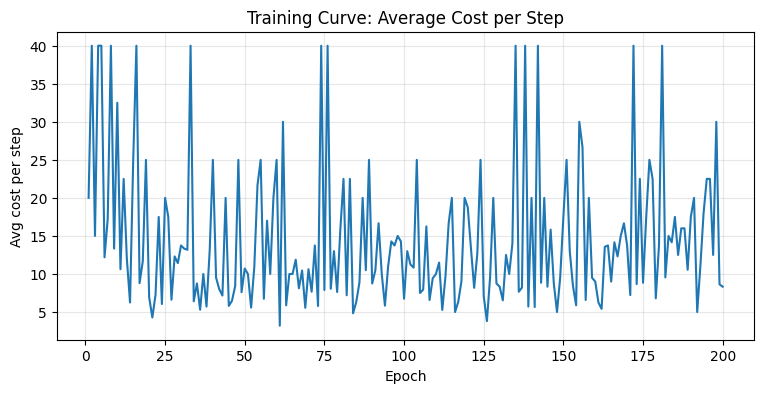

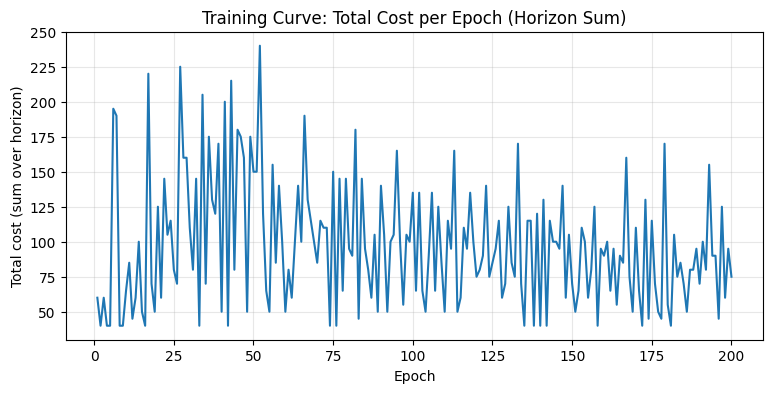

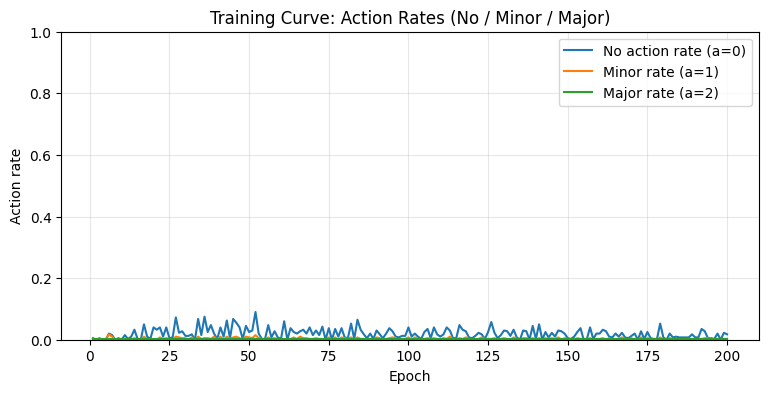

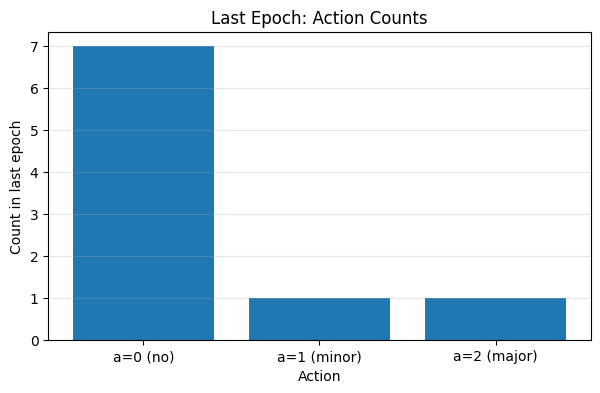

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 0) Basic sanity checks =====
# 【修复】使用实际存在的变量名 epoch_minor_count 和 epoch_major_count
need_vars = ["epoch_cost_avg", "epoch_cost_sum", "epoch_minor_count", "epoch_major_count", "epoch_a_counts", "Q", "iters_per_epoch"]
missing = [v for v in need_vars if v not in globals()]
if missing:
    raise NameError(f"Missing variables in scope: {missing}. Run training cell first.")

epochs = np.arange(1, len(epoch_cost_avg) + 1)

# 【修复】从 count 计算 rate
epoch_minor_rate = np.array(epoch_minor_count) / iters_per_epoch
epoch_major_rate = np.array(epoch_major_count) / iters_per_epoch

# ===== 1) Avg cost per step (best for comparing trends) =====
plt.figure(figsize=(9, 4))
plt.plot(epochs, epoch_cost_avg)
plt.xlabel("Epoch")
plt.ylabel("Avg cost per step")
plt.title("Training Curve: Average Cost per Step")
plt.grid(True, alpha=0.3)
plt.show()

# ===== 2) Total cost per epoch (400-step sum) =====
plt.figure(figsize=(9, 4))
plt.plot(epochs, epoch_cost_sum)
plt.xlabel("Epoch")
plt.ylabel("Total cost (sum over horizon)")
plt.title("Training Curve: Total Cost per Epoch (Horizon Sum)")
plt.grid(True, alpha=0.3)
plt.show()

# ===== 3) Action rates (no / minor / major) per epoch =====
# Use epoch_a_counts (more robust than 1 - minor - major)
counts = np.array(epoch_a_counts, dtype=float)  # shape (N_total, 3)
rate_no    = counts[:, 0] / iters_per_epoch
rate_minor = counts[:, 1] / iters_per_epoch
rate_major = counts[:, 2] / iters_per_epoch

plt.figure(figsize=(9, 4))
plt.plot(epochs, rate_no,    label="No action rate (a=0)")
plt.plot(epochs, rate_minor, label="Minor rate (a=1)")
plt.plot(epochs, rate_major, label="Major rate (a=2)")
plt.xlabel("Epoch")
plt.ylabel("Action rate")
plt.title("Training Curve: Action Rates (No / Minor / Major)")
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ===== 4) Last epoch action counts bar =====
last_counts = np.array(epoch_a_counts[-1], dtype=int)  # [count_a0, count_a1, count_a2]
plt.figure(figsize=(7, 4))
plt.bar(["a=0 (no)", "a=1 (minor)", "a=2 (major)"], last_counts)
plt.xlabel("Action")
plt.ylabel("Count in last epoch")
plt.title("Last Epoch: Action Counts")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# DRL部分

In [56]:
# ==========================================
# DRL 0. 变量扫描 & 配置
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# 设置随机种子保证可复现性
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 扫描 notebook 变量，定位列名
UNIT_COL = 'unit_nr'
AGE_COL = 'time_cycles'
RISK_COL = 'HR'  # 使用连续的 hazard risk

# 验证变量存在
assert UNIT_COL in df_process.columns, f"Missing {UNIT_COL}"
assert AGE_COL in df_process.columns, f"Missing {AGE_COL}"
assert RISK_COL in df_process.columns, f"Missing {RISK_COL}"

# 复用 notebook 已有的 R_action
if 'R_action' in dir():
    print("Using existing R_action:", R_action)
else:
    R_action = np.array([0.0, -20.0, -40.0])
    print("Fallback R_action:", R_action)

print(f"\nColumn mapping: UNIT={UNIT_COL}, AGE={AGE_COL}, RISK={RISK_COL}")
print(f"df_process shape: {df_process.shape}")
print(f"Total units: {df_process[UNIT_COL].nunique()}")

Using existing R_action: [  0. -20. -40.]

Column mapping: UNIT=unit_nr, AGE=time_cycles, RISK=HR
df_process shape: (160359, 29)
Total units: 709


In [57]:
# ==========================================
# DRL 1. Minor Repair 定义：age rollback + hazard reduction + diminishing returns
# ==========================================

# ----- Minor repair 参数（可调）-----
R0 = 0.30       # age rollback 基础比例
ETA0 = 0.25     # hazard reduction 基础比例
DECAY = 0.15    # 衰减率（k_minor 增加时效果递减）

# ----- 计算 h_min（防止 "better than new"）-----
# 使用前 5 个 cycle 的 hazard risk 的 1% 分位数
early_cycles = df_process[df_process[AGE_COL] <= 5][RISK_COL].values
h_min = max(np.percentile(early_cycles, 1), 1e-6)
print(f"h_min (防止过度修复): {h_min:.6e}")

# 全局 hazard 统计
h_global_min = df_process[RISK_COL].min()
h_global_max = df_process[RISK_COL].max()
h_global_median = df_process[RISK_COL].median()
print(f"Hazard risk 统计: min={h_global_min:.4e}, median={h_global_median:.4e}, max={h_global_max:.4e}")

def compute_minor_repair_effectiveness(k_minor):
    """
    计算第 k_minor 次小修的效果（含衰减）
    返回: r_k (age rollback ratio), eta_k (hazard reduction ratio)
    """
    r_k = R0 * np.exp(-DECAY * k_minor)
    eta_k = ETA0 * np.exp(-DECAY * k_minor)
    return r_k, eta_k

def apply_minor_repair(age_current, h_current, k_minor, unit_df):
    """
    执行小修：
    1. 计算衰减后的效果 r_k, eta_k
    2. age_after = floor((1 - r_k) * age_current)
    3. 映射回该 unit 的历史轨迹找到对应的 hazard
    4. h_after = max(h_min, (1 - eta_k) * h_from_traj)
    5. 关键约束: h_after 不能大于 h_current（小修不能让情况变差）

    返回: (age_after, h_after, fallback_flag)
    """
    r_k, eta_k = compute_minor_repair_effectiveness(k_minor)

    # Age rollback
    age_after = int(np.floor((1 - r_k) * age_current))
    age_after = max(age_after, 1)  # 至少为 1

    # 映射回轨迹：找 time_cycles 最接近 age_after 且 <= age_current 的行
    fallback = False
    candidates = unit_df[unit_df[AGE_COL] <= age_after]

    if len(candidates) > 0:
        # 找最接近 age_after 的
        matched_row = candidates.iloc[(candidates[AGE_COL] - age_after).abs().argmin()]
        h_from_traj = matched_row[RISK_COL]
        age_after = int(matched_row[AGE_COL])
    else:
        # Fallback: 找该 unit 最小的 age
        matched_row = unit_df.iloc[0]
        h_from_traj = matched_row[RISK_COL]
        age_after = int(matched_row[AGE_COL])
        fallback = True

    # Hazard reduction: 基于映射回的轨迹点应用折扣
    h_after_raw = (1 - eta_k) * h_from_traj

    # 关键约束: h_after 不能大于 h_current（小修不能让情况变差）
    # 同时不能低于 h_min（不能比全新还好）
    h_after = max(h_min, min(h_after_raw, h_current))

    return age_after, h_after, fallback

print("\nMinor repair 参数:")
print(f"  R0={R0}, ETA0={ETA0}, DECAY={DECAY}")
print(f"  k=0 时: r_k={R0:.3f}, eta_k={ETA0:.3f}")
print(f"  k=3 时: r_k={R0*np.exp(-DECAY*3):.3f}, eta_k={ETA0*np.exp(-DECAY*3):.3f}")
print(f"  k=5 时: r_k={R0*np.exp(-DECAY*5):.3f}, eta_k={ETA0*np.exp(-DECAY*5):.3f}")

h_min (防止过度修复): 4.218813e-06
Hazard risk 统计: min=1.3326e-07, median=1.4323e+00, max=1.4565e+05

Minor repair 参数:
  R0=0.3, ETA0=0.25, DECAY=0.15
  k=0 时: r_k=0.300, eta_k=0.250
  k=3 时: r_k=0.191, eta_k=0.159
  k=5 时: r_k=0.142, eta_k=0.118


In [58]:
# ==========================================
# DRL 2. Sanity Check #1: 小修应该降低 hazard 且不低于 h_min
# ==========================================

print("=" * 60)
print("Sanity Check #1: Minor repair reduces hazard but not below h_min")
print("=" * 60)

N_samples = 1000
violations_reduce = []
violations_lower_bound = []

# 随机采样 N 个状态
sampled_rows = df_process.sample(n=N_samples, random_state=SEED)

for idx, row in sampled_rows.iterrows():
    unit_id = row[UNIT_COL]
    age_before = int(row[AGE_COL])
    h_before = row[RISK_COL]

    # 获取该 unit 的完整轨迹
    unit_df = df_process[df_process[UNIT_COL] == unit_id].sort_values(AGE_COL)

    # 执行一次小修 (k_minor=0)
    age_after, h_after, fallback = apply_minor_repair(age_before, h_before, k_minor=0, unit_df=unit_df)

    # 检查约束
    tol = 1e-9
    if h_after > h_before + tol:
        violations_reduce.append({
            'unit_id': unit_id, 'age': age_before,
            'h_before': h_before, 'h_after': h_after,
            'delta': h_after - h_before
        })

    if h_after < h_min - tol:
        violations_lower_bound.append({
            'unit_id': unit_id, 'age': age_before,
            'h_before': h_before, 'h_after': h_after
        })

print(f"\n采样数: {N_samples}")
print(f"违反「h_after <= h_before」的数量: {len(violations_reduce)}")
print(f"违反「h_after >= h_min」的数量: {len(violations_lower_bound)}")

if len(violations_reduce) > 0:
    print("\n⚠️ Top 5 违反 reduce 约束的样本:")
    for v in violations_reduce[:5]:
        print(f"  unit={v['unit_id']}, age={v['age']}, h_before={v['h_before']:.4e}, h_after={v['h_after']:.4e}, delta={v['delta']:.4e}")
    print("  建议: 降低 ETA0 或检查轨迹映射逻辑")

if len(violations_lower_bound) > 0:
    print("\n⚠️ Top 5 违反 lower bound 约束的样本:")
    for v in violations_lower_bound[:5]:
        print(f"  unit={v['unit_id']}, age={v['age']}, h_before={v['h_before']:.4e}, h_after={v['h_after']:.4e}")
    print("  建议: 提高 h_min 分位数")

if len(violations_reduce) == 0 and len(violations_lower_bound) == 0:
    print("\n✅ Sanity Check #1 通过: 小修正确降低 hazard 且不低于 h_min")

Sanity Check #1: Minor repair reduces hazard but not below h_min

采样数: 1000
违反「h_after <= h_before」的数量: 1
违反「h_after >= h_min」的数量: 0

⚠️ Top 5 违反 reduce 约束的样本:
  unit=703.0, age=140, h_before=1.0932e-06, h_after=4.2188e-06, delta=3.1256e-06
  建议: 降低 ETA0 或检查轨迹映射逻辑


In [59]:
# ==========================================
# DRL 3. Sanity Check #2: 连续小修边际收益递减
# ==========================================

print("=" * 60)
print("Sanity Check #2: Diminishing returns for repeated minor repairs")
print("=" * 60)

M_samples = 200
K_repeats = 5

# 存储每次小修的 delta
deltas_by_step = {k: [] for k in range(K_repeats)}

# 随机采样 M 个起始状态
sampled_starts = df_process.sample(n=M_samples, random_state=SEED+1)

for idx, row in sampled_starts.iterrows():
    unit_id = row[UNIT_COL]
    unit_df = df_process[df_process[UNIT_COL] == unit_id].sort_values(AGE_COL)

    age_curr = int(row[AGE_COL])
    h_curr = row[RISK_COL]

    for k in range(K_repeats):
        # 执行第 k 次小修
        age_next, h_next, _ = apply_minor_repair(age_curr, h_curr, k_minor=k, unit_df=unit_df)

        delta = h_curr - h_next  # 正值表示 hazard 降低
        deltas_by_step[k].append(delta)

        # 更新状态（但不沿轨迹前进，只是连续小修）
        age_curr = age_next
        h_curr = h_next

# 计算统计量
print(f"\n采样数: {M_samples}, 连续小修次数: {K_repeats}")
print("\n步骤  | 平均 delta | 标准差 delta | 正值比例")
print("-" * 50)

mean_deltas = []
for k in range(K_repeats):
    deltas = np.array(deltas_by_step[k])
    mean_d = np.mean(deltas)
    std_d = np.std(deltas)
    positive_rate = np.mean(deltas > 0)
    mean_deltas.append(mean_d)
    print(f"  {k+1}   |  {mean_d:+.4e}  |  {std_d:.4e}  |  {positive_rate:.2%}")

# 检查边际收益是否递减
violations = 0
for k in range(1, K_repeats):
    if mean_deltas[k] > mean_deltas[k-1] + 1e-9:
        violations += 1

print(f"\n边际收益递减违反次数: {violations}/{K_repeats-1}")

if violations == 0:
    print("✅ Sanity Check #2 通过: 连续小修边际收益递减")
else:
    print("⚠️ 存在违反: 考虑增大 DECAY 参数")

Sanity Check #2: Diminishing returns for repeated minor repairs

采样数: 200, 连续小修次数: 5

步骤  | 平均 delta | 标准差 delta | 正值比例
--------------------------------------------------
  1   |  +6.9991e+02  |  5.6048e+03  |  64.00%
  2   |  +3.4281e+00  |  1.3900e+01  |  49.00%
  3   |  +7.4444e-01  |  5.1077e+00  |  30.00%
  4   |  +1.0964e-01  |  6.0802e-01  |  26.50%
  5   |  +6.3774e-02  |  3.5240e-01  |  20.50%

边际收益递减违反次数: 0/4
✅ Sanity Check #2 通过: 连续小修边际收益递减


In [60]:
# ==========================================
# DRL 4. 环境定义: MaintenanceEnv (连续 state)
# ==========================================
"""
【论文口径】Major maintenance (a=2) 的处理：
  "major maintenance will bring the system to healthy state,
   thus each epoch terminates if major repair action is taken (a=2)"

实现要点：
1. action==2 时：done=True，next_state 重置为 healthy (hazard=h_min, age=0)
2. 不做动作屏蔽：允许在任何状态选择 a=2
3. episode 长度不固定（major repair 会提前终止）
"""

class MaintenanceEnv:
    """
    维护决策环境（连续 state 版本）
    - state: (hazard_risk, age) 连续值，归一化到 [0,1]
    - action: 0=no repair, 1=minor repair, 2=major repair
    - 基于真实轨迹数据驱动

    【论文口径】
    - Major repair (a=2) 将系统恢复到健康状态并终止当前 episode
    - 不做动作约束，允许在任何状态选择任何动作
    """

    def __init__(self, df, unit_col, age_col, risk_col, r_action,
                 h_min, r0=0.30, eta0=0.25, decay=0.15, max_steps=400):
        self.df = df.copy()
        self.unit_col = unit_col
        self.age_col = age_col
        self.risk_col = risk_col
        self.r_action = r_action
        self.h_min = h_min
        self.r0 = r0
        self.eta0 = eta0
        self.decay = decay
        self.max_steps = max_steps

        # 按 unit 分组并排序
        self.units = df[unit_col].unique()
        self.unit_trajectories = {}
        for u in self.units:
            self.unit_trajectories[u] = df[df[unit_col] == u].sort_values(age_col).reset_index(drop=True)

        # 状态归一化参数
        self.h_max = df[risk_col].max()
        self.age_max = df[age_col].max()

        self.reset()

    def reset(self, unit_id=None):
        """重置环境，开始新 episode"""
        if unit_id is None:
            self.current_unit = np.random.choice(self.units)
        else:
            self.current_unit = unit_id

        self.unit_df = self.unit_trajectories[self.current_unit].copy()
        self.current_idx = 0
        self.k_minor = 0  # 小修次数计数器
        self.steps = 0
        self.done = False

        row = self.unit_df.iloc[self.current_idx]
        self.current_h = row[self.risk_col]
        self.current_age = int(row[self.age_col])

        return self._get_state()

    def _get_state(self):
        """返回归一化后的状态向量"""
        h_norm = self.current_h / (self.h_max + 1e-12)
        age_norm = self.current_age / (self.age_max + 1e-12)
        return np.array([h_norm, age_norm], dtype=np.float32)

    def _get_healthy_state(self):
        """返回健康状态的归一化向量（用于 major repair 后）"""
        h_norm = self.h_min / (self.h_max + 1e-12)
        age_norm = 0.0  # age 重置为 0
        return np.array([h_norm, age_norm], dtype=np.float32)

    def _compute_minor_effectiveness(self):
        """计算当前小修效果（含衰减）"""
        r_k = self.r0 * np.exp(-self.decay * self.k_minor)
        eta_k = self.eta0 * np.exp(-self.decay * self.k_minor)
        return r_k, eta_k

    def step(self, action):
        """
        执行动作，返回 (next_state, reward, done, info)

        【论文口径】
        - action==2 (major repair): done=True, next_state 重置为健康状态
        - action==0,1: done=False (除非到达轨迹末尾或 max_steps)
        - 不做动作屏蔽：允许在任何状态选择 a=2
        """
        if self.done:
            raise ValueError("Episode already done. Call reset().")

        info = {
            'action': action,
            'unit': self.current_unit,
            'k_minor': self.k_minor,
            'major_repair': False  # 默认
        }
        reward = float(self.r_action[action])

        # ===== Action 0: No repair =====
        if action == 0:
            self.current_idx += 1
            if self.current_idx >= len(self.unit_df):
                self.done = True
                info['termination'] = 'end_of_trajectory'
            else:
                row = self.unit_df.iloc[self.current_idx]
                self.current_h = row[self.risk_col]
                self.current_age = int(row[self.age_col])

        # ===== Action 1: Minor repair =====
        elif action == 1:
            r_k, eta_k = self._compute_minor_effectiveness()

            # Age rollback
            age_after = int(np.floor((1 - r_k) * self.current_age))
            age_after = max(age_after, 1)

            # 映射回轨迹
            candidates = self.unit_df[self.unit_df[self.age_col] <= age_after]
            if len(candidates) > 0:
                matched_idx = (candidates[self.age_col] - age_after).abs().idxmin()
                matched_row = self.unit_df.loc[matched_idx]
                h_from_traj = matched_row[self.risk_col]
                rollback_idx = self.unit_df.index.get_loc(matched_idx)
            else:
                # Fallback to first row
                matched_row = self.unit_df.iloc[0]
                h_from_traj = matched_row[self.risk_col]
                rollback_idx = 0
                info['fallback'] = True

            # Hazard reduction - 添加约束：小修不能让情况变差
            h_before = self.current_h
            h_after_raw = (1 - eta_k) * h_from_traj
            # 关键约束: h_after 在 [h_min, h_before] 范围内
            self.current_h = max(self.h_min, min(h_after_raw, h_before))
            self.current_age = int(matched_row[self.age_col])

            self.k_minor += 1
            info['r_k'] = r_k
            info['eta_k'] = eta_k

            # 小修后推进一个时间步（从回滚位置向前一步）
            self.current_idx = rollback_idx + 1
            if self.current_idx >= len(self.unit_df):
                self.done = True
                info['termination'] = 'end_of_trajectory_after_minor'
            else:
                row = self.unit_df.iloc[self.current_idx]
                self.current_age = int(row[self.age_col])

        # ===== Action 2: Major repair =====
        elif action == 2:
            # 【论文口径】Major repair 将系统恢复到健康状态并终止 episode
            self.done = True
            info['termination'] = 'major_repair'
            info['major_repair'] = True

            # 重置内部状态到健康状态（虽然 episode 结束了，但 next_state 应反映健康状态）
            self.current_h = self.h_min
            self.current_age = 0
            self.k_minor = 0  # 小修计数器也重置

        self.steps += 1
        if self.steps >= self.max_steps and not self.done:
            self.done = True
            info['termination'] = 'max_steps'

        return self._get_state(), reward, self.done, info

# 创建环境实例
env = MaintenanceEnv(
    df=df_process,
    unit_col=UNIT_COL,
    age_col=AGE_COL,
    risk_col=RISK_COL,
    r_action=R_action,
    h_min=h_min,
    r0=R0,
    eta0=ETA0,
    decay=DECAY,
    max_steps=400
)

print("=" * 60)
print("MaintenanceEnv 创建完成")
print("=" * 60)
print(f"  Units: {len(env.units)}")
print(f"  State dim: 2 (h_norm, age_norm)")
print(f"  Action space: 3 (no repair, minor, major)")
print(f"  Max steps per episode: {env.max_steps}")
print(f"\n【论文口径】")
print(f"  - Major repair (a=2) 将系统恢复到健康状态并终止 episode")
print(f"  - 不做动作约束：允许在任何状态选择任何动作")
print(f"  - Episode 长度不固定（major repair 会提前终止）")

# ==========================================
# 自检验证：Major repair 正确性测试
# ==========================================
print("\n" + "=" * 60)
print("🔍 自检验证: Major Repair 正确性")
print("=" * 60)

# 测试 1: 从任意状态执行 major repair
test_state = env.reset()
print(f"\n[Test 1] 从随机状态执行 major repair")
print(f"  初始状态: h_norm={test_state[0]:.4f}, age_norm={test_state[1]:.4f}")

next_state, reward, done, info = env.step(2)  # major repair

# 验证
healthy_state = env._get_healthy_state()
assert done == True, f"ERROR: done should be True after major repair, got {done}"
assert info['major_repair'] == True, f"ERROR: major_repair flag should be True"
assert np.allclose(next_state, healthy_state, atol=1e-6), \
    f"ERROR: next_state should be healthy state. Got {next_state}, expected {healthy_state}"

print(f"  动作: 2 (major repair)")
print(f"  Reward: {reward}")
print(f"  Done: {done} ✅")
print(f"  Next state (healthy): h_norm={next_state[0]:.4f}, age_norm={next_state[1]:.4f} ✅")
print(f"  info['major_repair']: {info['major_repair']} ✅")

# 测试 2: 多次采样验证
print(f"\n[Test 2] 多次采样验证 major repair 一致性")
n_tests = 10
all_passed = True
for i in range(n_tests):
    state = env.reset()
    # 先执行几步随机动作（不含 major）
    for _ in range(np.random.randint(1, 5)):
        if env.done:
            break
        a = np.random.choice([0, 1])  # 不执行 major
        env.step(a)

    if not env.done:
        # 从当前状态执行 major repair
        current_state = env._get_state()
        next_state, reward, done, info = env.step(2)

        if not (done == True and info['major_repair'] == True):
            print(f"  Test {i+1}: FAILED - done={done}, major_repair={info.get('major_repair')}")
            all_passed = False

if all_passed:
    print(f"  {n_tests}/{n_tests} 测试通过 ✅")
else:
    print(f"  部分测试失败 ❌")

print("\n" + "=" * 60)
print("✅ 环境自检完成")
print("=" * 60)

MaintenanceEnv 创建完成
  Units: 709
  State dim: 2 (h_norm, age_norm)
  Action space: 3 (no repair, minor, major)
  Max steps per episode: 400

【论文口径】
  - Major repair (a=2) 将系统恢复到健康状态并终止 episode
  - 不做动作约束：允许在任何状态选择任何动作
  - Episode 长度不固定（major repair 会提前终止）

🔍 自检验证: Major Repair 正确性

[Test 1] 从随机状态执行 major repair
  初始状态: h_norm=0.0000, age_norm=0.0018
  动作: 2 (major repair)
  Reward: -40.0
  Done: True ✅
  Next state (healthy): h_norm=0.0000, age_norm=0.0000 ✅
  info['major_repair']: True ✅

[Test 2] 多次采样验证 major repair 一致性
  10/10 测试通过 ✅

✅ 环境自检完成


In [62]:
# ==========================================
# DRL 5. Replay Buffer
# ==========================================

class ReplayBuffer:
    """经验回放缓冲区"""

    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

print("ReplayBuffer 定义完成")

ReplayBuffer 定义完成


In [64]:
# ==========================================
# DRL 6. Q-Network (标准 DQN: 线性输出)
# ==========================================

class QNetwork(nn.Module):
    """
    标准 DQN Q-Network：
    - 输入: 2 维 (h_norm, age_norm)
    - 隐藏层: 512 节点, ReLU 激活 (比 sigmoid 更稳定)
    - 输出: 3 维, **线性输出** (标准 Q 值回归)

    【修改说明】
    原代码使用 softmax 输出，这与 DQN 的 TD 回归损失不兼容：
    - softmax 输出受限于 (0,1) 且和为 1
    - TD target 可以是任意实数
    - 导致目标与输出空间不匹配，引发动作塌缩

    标准 DQN 使用线性输出层，让 Q 值可以是任意实数。
    """

    def __init__(self, state_dim=2, action_dim=3, hidden_dim=512):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # 使用 ReLU 替代 sigmoid (更稳定的梯度)
        x = self.fc2(x)              # 【关键】线性输出，无 softmax
        return x

# 创建网络
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
q_net = QNetwork().to(device)
target_net = QNetwork().to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()  # target network 始终处于 eval 模式

print(f"QNetwork 创建完成 (device: {device})")
print(f"【重要修改】输出层: 线性 (无 softmax)")
print(q_net)

# 测试前向传播
test_state = torch.tensor([[0.5, 0.3]], dtype=torch.float32).to(device)
test_output = q_net(test_state)
print(f"\n测试输入: {test_state.cpu().numpy()}")
print(f"测试输出 (raw Q-values): {test_output.detach().cpu().numpy()}")

QNetwork 创建完成 (device: cpu)
【重要修改】输出层: 线性 (无 softmax)
QNetwork(
  (fc1): Linear(in_features=2, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=3, bias=True)
)

测试输入: [[0.5 0.3]]
测试输出 (raw Q-values): [[-0.2058906   0.13881275  0.10033937]]


In [65]:
# ==========================================
# DRL 7. 训练配置 & 辅助函数
# ==========================================

# ----- 超参数 (Paper) -----
DRL_EPOCHS = 200
DRL_GAMMA = 0.99
DRL_LR = 1e-3
DRL_BATCH_SIZE = 64
DRL_BUFFER_SIZE = 100000
DRL_EPS_MAX = 1.0
DRL_EPS_MIN = 1.0 / DRL_EPOCHS
DRL_EPS_DECAY = 0.1
DRL_TARGET_UPDATE = 10  # 每 10 个 epoch 更新 target network
DRL_GRAD_CLIP = 1.0

# ----- Epsilon schedule -----
def get_epsilon(epoch):
    return DRL_EPS_MIN + (DRL_EPS_MAX - DRL_EPS_MIN) * np.exp(-DRL_EPS_DECAY * epoch)

# ----- 选择动作 -----
def select_action(state, epsilon):
    if random.random() < epsilon:
        return random.randint(0, 2)
    else:
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            q_values = q_net(state_t)
            return q_values.argmax(dim=1).item()

# ----- Train/Test split by unit -----
all_units = df_process[UNIT_COL].unique()
np.random.seed(SEED)
np.random.shuffle(all_units)
split_idx = int(len(all_units) * 0.8)
train_units = all_units[:split_idx]
test_units = all_units[split_idx:]

print(f"DRL 超参数:")
print(f"  Epochs: {DRL_EPOCHS}")
print(f"  Gamma: {DRL_GAMMA}")
print(f"  Learning rate: {DRL_LR}")
print(f"  Batch size: {DRL_BATCH_SIZE}")
print(f"  Buffer size: {DRL_BUFFER_SIZE}")
print(f"  Epsilon: {DRL_EPS_MAX} -> {DRL_EPS_MIN}")
print(f"\n训练集 units: {len(train_units)}, 测试集 units: {len(test_units)}")

DRL 超参数:
  Epochs: 200
  Gamma: 0.99
  Learning rate: 0.001
  Batch size: 64
  Buffer size: 100000
  Epsilon: 1.0 -> 0.005

训练集 units: 567, 测试集 units: 142


In [66]:
# ==========================================
# DRL 8. 训练/加载模型 (标准 DQN 版)
# ==========================================
"""
【论文口径实现】

1. Q-Network 输出：线性输出 3 个 Q 值（已在 DRL 6 中修改）
2. TD target：标准形式 target = r + gamma*(1-done)*max_a' Q_target(s',a')
3. Loss：HuberLoss (SmoothL1Loss)
4. Reward：直接使用原始 reward，不做归一化
5. Major repair (a=2)：立即终止 episode，状态重置为 healthy

【统计口径】
- Total cost: 累计 -(action_cost + state_cost)
- Episode steps: 每个 episode 的实际步数（major repair 会提前终止）
- Minor/Major actions: 每个 episode 的动作统计
"""

import os
import json

# ==========================================
# 配置: 模型文件路径
# ==========================================
MODEL_PATH = "drl_maintenance_model.pth"
HISTORY_PATH = "drl_training_history.json"
OBJECTS_PATH = "drl_essential_objects.pkl"
FORCE_RETRAIN = False  # 设置为 False 以加载已保存的模型，不重新训练

# ==========================================
# 状态运行成本函数
# ==========================================
def get_state_cost(hazard_norm):
    """
    状态运行成本：惩罚高 hazard 状态
    - hazard_norm ∈ [0, 1]
    - 返回负值（成本）
    """
    if hazard_norm < 0.3:
        return 0.0       # 低风险：无成本
    elif hazard_norm < 0.5:
        return -5.0      # 中低风险
    elif hazard_norm < 0.7:
        return -10.0     # 中高风险
    else:
        return -20.0     # 高风险：重惩罚

# ==========================================
# 检查是否存在已训练模型
# ==========================================
model_exists = os.path.exists(MODEL_PATH)

if model_exists and not FORCE_RETRAIN:
    print("=" * 60)
    print("✅ 检测到已有模型，加载中...")
    print(f"   模型路径: {MODEL_PATH}")
    print("=" * 60)

    checkpoint = torch.load(MODEL_PATH, map_location=device)
    q_net.load_state_dict(checkpoint['model_state_dict'])
    target_net.load_state_dict(checkpoint['target_state_dict'])
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=DRL_LR)
    if 'optimizer_state_dict' in checkpoint:
        try:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        except:
            pass

    print(f"\n✅ 模型加载完成!")
    print(f"   训练 Epoch: {checkpoint.get('epoch', 'N/A')}")

    if os.path.exists(HISTORY_PATH):
        try:
            with open(HISTORY_PATH, 'r') as f:
                history_data = json.load(f)
            train_losses = history_data.get('train_losses', [])
            train_episode_costs = history_data.get('train_episode_costs', [])
            train_action_counts = [np.array(c) for c in history_data.get('train_action_counts', [])]
            train_episode_steps = history_data.get('train_episode_steps', [])
            train_minor_counts = history_data.get('train_minor_counts', [])
            train_major_counts = history_data.get('train_major_counts', [])
            print(f"✅ 训练历史已从 {HISTORY_PATH} 加载")
        except:
            train_losses, train_episode_costs, train_action_counts = [], [], []
            train_episode_steps, train_minor_counts, train_major_counts = [], [], []
    else:
        train_losses, train_episode_costs, train_action_counts = [], [], []
        train_episode_steps, train_minor_counts, train_major_counts = [], [], []

else:
    # ==========================================
    # 开始训练模型 (标准 DQN)
    # ==========================================
    print("=" * 60)
    print("🏋️  开始训练 (标准 DQN)...")
    print("=" * 60)

    print(f"\n【论文口径】")
    print(f"  - Major repair (a=2) 将系统恢复到健康状态并终止 episode")
    print(f"  - 不做动作约束：允许在任何状态选择任何动作")
    print(f"  - Episode 长度不固定（major repair 会提前终止）")

    print(f"\nReward 设计 (原始值，不归一化):")
    print(f"  动作成本: {R_action}")
    print(f"  状态成本: hazard<0.3→0, 0.3-0.5→-5, 0.5-0.7→-10, >0.7→-20")

    # ----- 训练配置 -----
    TRAIN_FREQ = 4

    # 初始化
    replay_buffer = ReplayBuffer(capacity=DRL_BUFFER_SIZE)
    optimizer = optim.Adam(q_net.parameters(), lr=DRL_LR)
    loss_fn = nn.SmoothL1Loss()

    train_losses = []
    train_episode_costs = []
    train_action_counts = []
    train_episode_steps = []    # 每个 epoch 的平均 episode 步数
    train_minor_counts = []     # 每个 epoch 的平均 minor 次数
    train_major_counts = []     # 每个 epoch 的平均 major 次数
    total_steps = 0

    print(f"\n优化器: Adam (lr={DRL_LR})")
    print(f"损失函数: HuberLoss (SmoothL1Loss)")
    print(f"Gamma: {DRL_GAMMA}")
    print("\n开始 DRL 训练...")
    print("=" * 60)

    for epoch in range(DRL_EPOCHS):
        epsilon = get_epsilon(epoch)
        epoch_loss = 0.0
        epoch_cost = 0.0
        epoch_actions = np.zeros(3, dtype=int)
        epoch_episode_steps = []  # 每个 unit 的 episode 步数
        n_updates = 0

        q_net.train()

        for unit_id in train_units:
            state = env.reset(unit_id=unit_id)
            episode_cost = 0.0
            episode_steps = 0
            episode_actions = np.zeros(3, dtype=int)

            while not env.done:
                action = select_action(state, epsilon)
                next_state, action_reward, done, info = env.step(action)

                # 计算完整 reward
                state_cost = get_state_cost(next_state[0])
                total_reward = action_reward + state_cost

                replay_buffer.push(state, action, total_reward, next_state, done)

                episode_cost += (-total_reward)
                episode_actions[action] += 1
                episode_steps += 1
                total_steps += 1
                state = next_state

                # 训练
                if total_steps % TRAIN_FREQ == 0 and len(replay_buffer) >= DRL_BATCH_SIZE:
                    states_b, actions_b, rewards_b, next_states_b, dones_b = replay_buffer.sample(DRL_BATCH_SIZE)

                    states_t = torch.tensor(states_b, dtype=torch.float32).to(device)
                    actions_t = torch.tensor(actions_b, dtype=torch.long).to(device)
                    rewards_t = torch.tensor(rewards_b, dtype=torch.float32).to(device)
                    next_states_t = torch.tensor(next_states_b, dtype=torch.float32).to(device)
                    dones_t = torch.tensor(dones_b, dtype=torch.float32).to(device)

                    q_values = q_net(states_t)
                    q_sa = q_values.gather(1, actions_t.unsqueeze(1)).squeeze(1)

                    with torch.no_grad():
                        next_q_values = target_net(next_states_t)
                        max_next_q = next_q_values.max(dim=1)[0]
                        target = rewards_t + DRL_GAMMA * (1 - dones_t) * max_next_q

                    loss = loss_fn(q_sa, target)

                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(q_net.parameters(), DRL_GRAD_CLIP)
                    optimizer.step()

                    epoch_loss += loss.item()
                    n_updates += 1

            epoch_cost += episode_cost
            epoch_actions += episode_actions
            epoch_episode_steps.append(episode_steps)

        # 更新 target network
        if (epoch + 1) % DRL_TARGET_UPDATE == 0:
            target_net.load_state_dict(q_net.state_dict())
            target_net.eval()

        avg_loss = epoch_loss / max(n_updates, 1)
        avg_cost = epoch_cost / len(train_units)
        avg_steps = np.mean(epoch_episode_steps)
        avg_minor = epoch_actions[1] / len(train_units)
        avg_major = epoch_actions[2] / len(train_units)

        train_losses.append(avg_loss)
        train_episode_costs.append(avg_cost)
        train_action_counts.append(epoch_actions.copy())
        train_episode_steps.append(avg_steps)
        train_minor_counts.append(avg_minor)
        train_major_counts.append(avg_major)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            action_rate = epoch_actions / max(epoch_actions.sum(), 1)
            print(f"Epoch {epoch+1:3d}/{DRL_EPOCHS} | Loss: {avg_loss:.4f} | "
                  f"Avg Cost: {avg_cost:.2f} | Avg Steps: {avg_steps:.1f} | Eps: {epsilon:.3f}")
            print(f"          Actions: [no:{action_rate[0]:.1%}, minor:{action_rate[1]:.1%}, major:{action_rate[2]:.1%}] "
                  f"| Avg Minor: {avg_minor:.1f}, Avg Major: {avg_major:.2f}")

    print("=" * 60)
    print("✅ DRL 训练完成 (标准 DQN)")
    print("=" * 60)
    print(f"\n【训练统计】")
    print(f"  总训练步数: {total_steps}")
    print(f"\n【最后 10 epochs 平均值】")
    print(f"  Avg episode steps:  {np.mean(train_episode_steps[-10:]):.1f}")
    print(f"  Avg episode cost:   {np.mean(train_episode_costs[-10:]):.2f}")
    print(f"  Avg minor actions:  {np.mean(train_minor_counts[-10:]):.2f}")
    print(f"  Avg major actions:  {np.mean(train_major_counts[-10:]):.2f}")
    print(f"\n【注意】Episode 长度不固定（major repair 会提前终止）")

    # 保存模型
    print("\n保存模型...")
    torch.save({
        'epoch': DRL_EPOCHS,
        'model_state_dict': q_net.state_dict(),
        'target_state_dict': target_net.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'final_loss': train_losses[-1] if train_losses else 0.0,
    }, MODEL_PATH)
    print(f"✅ 模型已保存到: {MODEL_PATH}")

    history_data = {
        'train_losses': train_losses,
        'train_episode_costs': train_episode_costs,
        'train_action_counts': [c.tolist() for c in train_action_counts],
        'train_episode_steps': train_episode_steps,
        'train_minor_counts': train_minor_counts,
        'train_major_counts': train_major_counts,
    }
    with open(HISTORY_PATH, 'w') as f:
        json.dump(history_data, f, indent=2)
    print(f"✅ 训练历史已保存到: {HISTORY_PATH}")

    import pickle
    essential_objects = {
        'scaler': scaler, 'ctv': ctv, 'beta': beta, 'eta': eta, 'h_min': h_min,
        'R_action': R_action, 'R0': R0, 'ETA0': ETA0, 'DECAY': DECAY,
        'selected_features': selected_features,
        'train_units': train_units, 'test_units': test_units,
    }
    with open(OBJECTS_PATH, 'wb') as f:
        pickle.dump(essential_objects, f)
    print(f"✅ 关键对象已保存到: {OBJECTS_PATH}")

✅ 检测到已有模型，加载中...
   模型路径: drl_maintenance_model.pth


C:\Users\duper\AppData\Local\Temp\ipykernel_3292\2793178184.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=device)



✅ 模型加载完成!
   训练 Epoch: 200
✅ 训练历史已从 drl_training_history.json 加载


In [70]:
# ==========================================
# DRL v3.3: 启发式探索版 (Heuristic Exploration)
# ==========================================
"""
【核心改进】
1. 启发式探索：在高危状态强制执行维修动作，让模型"见过"正确操作
2. 固定高额故障惩罚：不再缓慢提升 C_fail，直接用高惩罚
3. 支持断点续训：如果模型文件存在，加载后继续训练

【问题诊断】
之前模型问题：No-Op 99.5%，Minor/Major 极少，Failures 高
原因分析：模型从未体验过"做维修后成功避免故障"的正反馈路径
"""

import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================
# 1. 配置
# ==========================================
MODEL_PATH_V33 = "drl_maintenance_model_v33.pth"
HISTORY_PATH_V33 = "drl_training_history_v33.json"

# 训练参数
DRL_EPOCHS_V33 = 100       # 本次训练轮数
CONTINUE_TRAINING = False  # 是否继续训练（如果模型存在）

# 核心惩罚参数
C_FAIL_FIXED = 2000.0       # 固定高额故障惩罚
COST_MINOR = 20.0          # Minor repair 成本
COST_MAJOR = 80.0          # Major repair 成本

# 启发式探索参数
HEURISTIC_MAJOR_THRESHOLD = 0.6    # hazard > 此值时可能强制 Major
HEURISTIC_MAJOR_PROB = 0.9         # 强制 Major 的概率
HEURISTIC_MINOR_THRESHOLD = 0.4    # hazard 在 [0.4, 0.7) 时可能强制 Minor
HEURISTIC_MINOR_PROB = 0.25         # 强制 Minor 的概率

# 简单的 Shaping (辅助，不主导)
LAMBDA_WARN_NOOP = 8.0       # 警告时不作为的惩罚 (hazard >= 0.3)
LAMBDA_CRITICAL_NOOP = 15.0  # 危险时不作为的惩罚 (hazard >= 0.5)
LAMBDA_MAJOR_BONUS = 10.0    # 高危做 Major 的奖励

# ==========================================
# 2. 初始化/加载模型
# ==========================================
print("=" * 70)
print("🚑 DRL v3.3: 启发式探索训练")
print("=" * 70)

# 检查是否存在已有模型
model_exists = os.path.exists(MODEL_PATH_V33)
start_epoch = 0

if model_exists and CONTINUE_TRAINING:
    print(f"\n📂 检测到已有模型: {MODEL_PATH_V33}")
    print("   加载模型继续训练...")
    
    # 加载模型
    q_net_v33 = QNetwork().to(device)
    target_net_v33 = QNetwork().to(device)
    
    checkpoint = torch.load(MODEL_PATH_V33, map_location=device, weights_only=False)
    q_net_v33.load_state_dict(checkpoint['model_state_dict'])
    
    if 'target_state_dict' in checkpoint:
        target_net_v33.load_state_dict(checkpoint['target_state_dict'])
    else:
        target_net_v33.load_state_dict(q_net_v33.state_dict())
    
    start_epoch = checkpoint.get('epoch', 0)
    print(f"   已完成 {start_epoch} epochs")
    
    # 加载历史
    if os.path.exists(HISTORY_PATH_V33):
        with open(HISTORY_PATH_V33, 'r') as f:
            history_v33 = json.load(f)
        print(f"   历史记录加载完成")
    else:
        history_v33 = {
            'train_losses': [], 'train_failures': [], 'train_steps': [],
            'train_noop_pct': [], 'train_minor_pct': [], 'train_major_pct': []
        }
else:
    print("\n🆕 创建新模型...")
    q_net_v33 = QNetwork().to(device)
    target_net_v33 = QNetwork().to(device)
    target_net_v33.load_state_dict(q_net_v33.state_dict())
    start_epoch = 0
    history_v33 = {
        'train_losses': [], 'train_failures': [], 'train_steps': [],
        'train_noop_pct': [], 'train_minor_pct': [], 'train_major_pct': []
    }

target_net_v33.eval()

# 优化器和 Buffer
replay_buffer_v33 = ReplayBuffer(capacity=DRL_BUFFER_SIZE)
optimizer_v33 = optim.Adam(q_net_v33.parameters(), lr=0.001)
loss_fn = nn.SmoothL1Loss()

print(f"\n【训练配置】")
print(f"  - 起始 Epoch: {start_epoch}")
print(f"  - 本次训练: {DRL_EPOCHS_V33} epochs")
print(f"  - 总目标: {start_epoch + DRL_EPOCHS_V33} epochs")
print(f"  - C_fail: {C_FAIL_FIXED}")
print(f"  - 启发式 Major: hazard > {HEURISTIC_MAJOR_THRESHOLD}, prob = {HEURISTIC_MAJOR_PROB}")
print(f"  - 启发式 Minor: hazard in [{HEURISTIC_MINOR_THRESHOLD}, {HEURISTIC_MAJOR_THRESHOLD}), prob = {HEURISTIC_MINOR_PROB}")

# ==========================================
# 3. 训练循环
# ==========================================
print("\n" + "=" * 70)
print("开始训练...")
print("=" * 70)

total_steps = 0
TRAIN_FREQ = 4

for epoch in range(DRL_EPOCHS_V33):
    actual_epoch = start_epoch + epoch + 1
    epsilon = get_epsilon(actual_epoch)  # 基于实际 epoch 计算探索率
    
    epoch_loss = 0.0
    epoch_actions = np.zeros(3, dtype=int)
    epoch_failures = 0
    epoch_steps_list = []
    n_updates = 0
    
    q_net_v33.train()
    
    for unit_id in train_units:
        state = env.reset(unit_id=unit_id)
        episode_steps = 0
        
        while not env.done:
            hazard_val = state[0]
            
            # # ==========================================
            # # 【关键】启发式探索策略
            # # ==========================================
            # # 高危状态 (hazard > 0.7): 强制 Major Repair
            # if hazard_val > HEURISTIC_MAJOR_THRESHOLD and random.random() < HEURISTIC_MAJOR_PROB:
            #     action = 2  # 强制 Major
            
            # # 中危状态 (0.4 <= hazard <= 0.7): 强制 Minor Repair
            # elif HEURISTIC_MINOR_THRESHOLD <= hazard_val <= HEURISTIC_MAJOR_THRESHOLD and random.random() < HEURISTIC_MINOR_PROB:
            #     action = 1  # 强制 Minor
            
            # # 常规 Epsilon-Greedy
            # elif random.random() < epsilon:
            #     action = random.randint(0, 2)
            
            # # 模型决策
            # else:
            #     with torch.no_grad():
            #         state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            #         q_vals = q_net_v33(state_t)
            #         action = q_vals.argmax(dim=1).item()


            # ==========================================
            # 🚑 暴力急救逻辑 (覆盖原有逻辑)
            # ==========================================
            # 只要 hazard 大于 0.6，彻底禁止神经网络思考
            if hazard_val > 0.6: 
                # 95% 的概率直接大修 (Major)
                if random.random() < 0.95: 
                    action = 2 
                # 5% 的概率做个小修 (Minor)
                # 绝对不给 No-Op (0) 的机会！
                else:
                    action = 1 
            
            # 只有在 hazard <= 0.6 (安全区) 时，才允许随机探索或模型决策
            elif random.random() < epsilon:
                action = random.randint(0, 2)
            else:
                with torch.no_grad():
                    state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                    q_vals = q_net_v33(state_t)
                    action = q_vals.argmax(dim=1).item()
            
            # ==========================================
            # 执行动作
            # ==========================================
            next_state, action_reward, done, info = env.step(action)
            
            # 计算 Reward
            r = action_reward + get_state_cost(next_state[0])
            
            # 故障惩罚
            term = info.get('termination', '')
            if done and term in ['end_of_trajectory', 'max_steps', 'end_of_trajectory_after_minor']:
                r -= C_FAIL_FIXED
                epoch_failures += 1
            
            # 简单 Shaping
            if hazard_val >= 0.3 and action == 0:
                r -= LAMBDA_WARN_NOOP
            if hazard_val >= 0.5 and action == 0:
                r -= LAMBDA_CRITICAL_NOOP
            if hazard_val >= 0.6 and action == 2:
                r += LAMBDA_MAJOR_BONUS
            
            # 存入 Buffer
            replay_buffer_v33.push(state, action, r, next_state, done)
            
            epoch_actions[action] += 1
            episode_steps += 1
            total_steps += 1
            state = next_state
            
            # 网络更新
            if total_steps % TRAIN_FREQ == 0 and len(replay_buffer_v33) >= DRL_BATCH_SIZE:
                states, actions, rewards, next_states, dones = replay_buffer_v33.sample(DRL_BATCH_SIZE)
                
                s_t = torch.tensor(states, dtype=torch.float32).to(device)
                a_t = torch.tensor(actions, dtype=torch.long).to(device)
                r_t = torch.tensor(rewards, dtype=torch.float32).to(device)
                ns_t = torch.tensor(next_states, dtype=torch.float32).to(device)
                d_t = torch.tensor(dones, dtype=torch.float32).to(device)
                
                curr_q = q_net_v33(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    max_next_q = target_net_v33(ns_t).max(1)[0]
                    target = r_t + DRL_GAMMA * (1 - d_t) * max_next_q
                
                loss = loss_fn(curr_q, target)
                optimizer_v33.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(q_net_v33.parameters(), 1.0)
                optimizer_v33.step()
                epoch_loss += loss.item()
                n_updates += 1
        
        epoch_steps_list.append(episode_steps)
    
    # 更新 Target Net
    if actual_epoch % DRL_TARGET_UPDATE == 0:
        target_net_v33.load_state_dict(q_net_v33.state_dict())
    
    # 统计
    avg_loss = epoch_loss / max(1, n_updates)
    avg_steps = np.mean(epoch_steps_list)
    total_actions = epoch_actions.sum()
    noop_pct = epoch_actions[0] / total_actions * 100 if total_actions > 0 else 0
    minor_pct = epoch_actions[1] / total_actions * 100 if total_actions > 0 else 0
    major_pct = epoch_actions[2] / total_actions * 100 if total_actions > 0 else 0
    
    history_v33['train_losses'].append(avg_loss)
    history_v33['train_failures'].append(epoch_failures)
    history_v33['train_steps'].append(avg_steps)
    history_v33['train_noop_pct'].append(noop_pct)
    history_v33['train_minor_pct'].append(minor_pct)
    history_v33['train_major_pct'].append(major_pct)
    
    # 打印进度
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {actual_epoch:3d} | Failures: {epoch_failures:3d} | Steps: {avg_steps:5.1f} | "
              f"No:{noop_pct:5.1f}% Mi:{minor_pct:5.1f}% Ma:{major_pct:5.1f}%")
    
    # 每 20 epochs 保存一次 checkpoint
    if (epoch + 1) % 20 == 0:
        torch.save({
            'epoch': actual_epoch,
            'model_state_dict': q_net_v33.state_dict(),
            'target_state_dict': target_net_v33.state_dict(),
            'optimizer_state_dict': optimizer_v33.state_dict(),
        }, MODEL_PATH_V33)
        with open(HISTORY_PATH_V33, 'w') as f:
            json.dump(history_v33, f)
        print(f"   💾 Checkpoint saved at epoch {actual_epoch}")

# ==========================================
# 4. 最终保存
# ==========================================
final_epoch = start_epoch + DRL_EPOCHS_V33

torch.save({
    'epoch': final_epoch,
    'model_state_dict': q_net_v33.state_dict(),
    'target_state_dict': target_net_v33.state_dict(),
    'optimizer_state_dict': optimizer_v33.state_dict(),
}, MODEL_PATH_V33)

with open(HISTORY_PATH_V33, 'w') as f:
    json.dump(history_v33, f)

print("\n" + "=" * 70)
print(f"✅ v3.3 训练完成！")
print(f"   总 Epochs: {final_epoch}")
print(f"   模型保存: {MODEL_PATH_V33}")
print(f"   历史保存: {HISTORY_PATH_V33}")
print("=" * 70)

# 替换全局模型变量以便后续评估
q_net = q_net_v33
target_net = target_net_v33

# 打印最后 20 epochs 统计
if len(history_v33['train_failures']) >= 20:
    print("\n【最后 20 epochs 统计】")
    print(f"  Avg Failures: {np.mean(history_v33['train_failures'][-20:]):.1f}")
    print(f"  Avg Steps: {np.mean(history_v33['train_steps'][-20:]):.1f}")
    print(f"  Avg No-Op: {np.mean(history_v33['train_noop_pct'][-20:]):.1f}%")
    print(f"  Avg Minor: {np.mean(history_v33['train_minor_pct'][-20:]):.1f}%")
    print(f"  Avg Major: {np.mean(history_v33['train_major_pct'][-20:]):.1f}%")

🚑 DRL v3.3: 启发式探索训练

🆕 创建新模型...

【训练配置】
  - 起始 Epoch: 0
  - 本次训练: 100 epochs
  - 总目标: 100 epochs
  - C_fail: 2000.0
  - 启发式 Major: hazard > 0.6, prob = 0.9
  - 启发式 Minor: hazard in [0.4, 0.6), prob = 0.25

开始训练...
Epoch   1 | Failures:   0 | Steps:   3.3 | No: 39.9% Mi: 29.6% Ma: 30.5%
Epoch  10 | Failures:   0 | Steps:   8.4 | No: 75.6% Mi: 12.5% Ma: 11.9%
Epoch  20 | Failures:   0 | Steps:  21.9 | No: 90.8% Mi:  4.6% Ma:  4.6%
   💾 Checkpoint saved at epoch 20
Epoch  30 | Failures:   6 | Steps:  57.1 | No: 96.4% Mi:  1.8% Ma:  1.7%
Epoch  40 | Failures:  74 | Steps: 114.1 | No: 98.5% Mi:  0.8% Ma:  0.8%
   💾 Checkpoint saved at epoch 40
Epoch  50 | Failures: 195 | Steps: 160.8 | No: 99.1% Mi:  0.5% Ma:  0.4%
Epoch  60 | Failures: 315 | Steps: 192.1 | No: 99.3% Mi:  0.4% Ma:  0.2%
   💾 Checkpoint saved at epoch 60
Epoch  70 | Failures: 363 | Steps: 206.1 | No: 99.4% Mi:  0.4% Ma:  0.2%
Epoch  80 | Failures: 370 | Steps: 213.2 | No: 99.4% Mi:  0.4% Ma:  0.2%
   💾 Checkpoint saved at ep

# 📊 DRL 模型评估与可视化

---

## 评估目标

本节对已训练的 DRL (DQN) 模型进行全面评估，重点关注：

1. **Episode 级别评估**：测试集上的累计成本、步数、故障率
2. **动作分布分析**：各动作的选择频率，检测极端策略
3. **随时间决策行为**：可视化具体 trajectory 的决策过程
4. **稳定性与可行性分析**：成本波动、提前终止情况

⚠️ **重要声明**：
- 本评估基于当前已训练模型，**不再修改或重新训练**
- 参数设置与原论文存在偏离，这是**已知且接受的事实**
- 评估目的是判断当前策略在**我的设定**下是否可用

In [71]:
# ==========================================
# EVAL 1. 评估工具函数定义
# ==========================================
"""
定义 DRL 评估所需的核心函数：
- evaluate_drl(): Episode 级别评估
- collect_trajectory(): 收集单个 episode 的完整轨迹
- baseline_policy(): 基线策略（用于对比）
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

# 确保中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 核心评估函数
# ==========================================

def evaluate_drl(model, env, test_units, n_episodes=50, deterministic=True, verbose=False):
    """
    在测试环境中评估 DRL 策略
    
    参数:
        model: 训练好的 QNetwork
        env: MaintenanceEnv 环境实例
        test_units: 用于测试的 unit ID 列表
        n_episodes: 评估的 episode 数量
        deterministic: 是否使用确定性策略（epsilon=0）
        verbose: 是否打印详细信息
    
    返回:
        results: dict，包含评估指标
    """
    model.eval()
    
    # 存储每个 episode 的结果
    episode_costs = []        # 累计总成本（action_cost + state_cost）
    episode_steps = []        # episode 长度
    episode_action_counts = []  # 每个 episode 的动作分布
    episode_terminations = []   # 终止原因
    episode_failures = []       # 是否故障终止
    
    # 循环评估
    for ep in range(n_episodes):
        # 随机选择一个测试 unit
        unit_id = np.random.choice(test_units)
        state = env.reset(unit_id=unit_id)
        
        total_cost = 0.0
        action_counts = np.zeros(3, dtype=int)  # [no-op, minor, major]
        steps = 0
        termination = None
        
        while not env.done:
            # 选择动作
            if deterministic:
                with torch.no_grad():
                    state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                    q_vals = model(state_t)
                    action = q_vals.argmax(dim=1).item()
            else:
                # 带探索的策略
                if np.random.random() < 0.05:
                    action = np.random.randint(0, 3)
                else:
                    with torch.no_grad():
                        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                        q_vals = model(state_t)
                        action = q_vals.argmax(dim=1).item()
            
            # 执行动作
            next_state, action_reward, done, info = env.step(action)
            
            # 计算成本 = 动作成本 + 状态运行成本
            # action_reward 已经是负的成本（如 -20, -80）
            state_cost = get_state_cost(next_state[0])  # 基于 hazard_norm
            step_cost = -action_reward + (-state_cost)  # 转换为正的成本
            total_cost += step_cost
            
            # 检查是否故障终止
            term = info.get('termination', '')
            if done:
                termination = term
                # 故障惩罚（非 major_repair 终止）
                if term in ['end_of_trajectory', 'max_steps', 'end_of_trajectory_after_minor']:
                    total_cost += C_FAIL_FIXED  # 加上故障成本
            
            action_counts[action] += 1
            steps += 1
            state = next_state
        
        # 记录结果
        episode_costs.append(total_cost)
        episode_steps.append(steps)
        episode_action_counts.append(action_counts)
        episode_terminations.append(termination)
        episode_failures.append(1 if termination in ['end_of_trajectory', 'max_steps', 'end_of_trajectory_after_minor'] else 0)
        
        if verbose and (ep + 1) % 10 == 0:
            print(f"Episode {ep+1}/{n_episodes}: Cost={total_cost:.1f}, Steps={steps}, Term={termination}")
    
    # 汇总统计
    episode_costs = np.array(episode_costs)
    episode_steps = np.array(episode_steps)
    episode_failures = np.array(episode_failures)
    action_matrix = np.array(episode_action_counts)
    
    results = {
        'n_episodes': n_episodes,
        # 成本统计
        'cost_mean': np.mean(episode_costs),
        'cost_std': np.std(episode_costs),
        'cost_min': np.min(episode_costs),
        'cost_max': np.max(episode_costs),
        'cost_median': np.median(episode_costs),
        # 步数统计
        'steps_mean': np.mean(episode_steps),
        'steps_std': np.std(episode_steps),
        'steps_min': np.min(episode_steps),
        'steps_max': np.max(episode_steps),
        # 故障统计
        'failure_rate': np.mean(episode_failures),
        'failure_count': np.sum(episode_failures),
        # 动作统计
        'action_total': action_matrix.sum(axis=0),
        'action_pct': action_matrix.sum(axis=0) / action_matrix.sum() * 100,
        # 原始数据
        'raw_costs': episode_costs,
        'raw_steps': episode_steps,
        'raw_actions': action_matrix,
        'raw_terminations': episode_terminations,
    }
    
    return results


def collect_trajectory(model, env, unit_id=None, deterministic=True):
    """
    收集单个 episode 的完整轨迹，用于可视化
    
    参数:
        model: 训练好的 QNetwork
        env: MaintenanceEnv 环境实例
        unit_id: 指定 unit（None 则随机选择）
        deterministic: 是否使用确定性策略
    
    返回:
        trajectory: dict，包含每一步的状态、动作、成本等
    """
    model.eval()
    
    if unit_id is None:
        unit_id = np.random.choice(env.units)
    
    state = env.reset(unit_id=unit_id)
    
    trajectory = {
        'unit_id': unit_id,
        'states': [state.copy()],
        'hazard_norms': [state[0]],
        'age_norms': [state[1]],
        'actions': [],
        'action_names': [],
        'action_costs': [],
        'state_costs': [],
        'step_costs': [],
        'cumulative_costs': [],
        'q_values': [],
    }
    
    cumulative = 0.0
    action_names_map = {0: 'No-Op', 1: 'Minor', 2: 'Major'}
    
    while not env.done:
        # 获取 Q 值
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            q_vals = model(state_t).cpu().numpy().flatten()
        
        # 选择动作
        if deterministic:
            action = np.argmax(q_vals)
        else:
            if np.random.random() < 0.05:
                action = np.random.randint(0, 3)
            else:
                action = np.argmax(q_vals)
        
        # 执行动作
        next_state, action_reward, done, info = env.step(action)
        
        # 计算成本
        action_cost = -action_reward
        state_cost = -get_state_cost(next_state[0])
        step_cost = action_cost + state_cost
        
        # 故障惩罚
        term = info.get('termination', '')
        if done and term in ['end_of_trajectory', 'max_steps', 'end_of_trajectory_after_minor']:
            step_cost += C_FAIL_FIXED
        
        cumulative += step_cost
        
        # 记录
        trajectory['actions'].append(action)
        trajectory['action_names'].append(action_names_map[action])
        trajectory['action_costs'].append(action_cost)
        trajectory['state_costs'].append(state_cost)
        trajectory['step_costs'].append(step_cost)
        trajectory['cumulative_costs'].append(cumulative)
        trajectory['q_values'].append(q_vals)
        trajectory['states'].append(next_state.copy())
        trajectory['hazard_norms'].append(next_state[0])
        trajectory['age_norms'].append(next_state[1])
        
        state = next_state
    
    trajectory['termination'] = info.get('termination', 'unknown')
    trajectory['total_cost'] = cumulative
    trajectory['total_steps'] = len(trajectory['actions'])
    
    return trajectory


def baseline_no_maintenance(env, test_units, n_episodes=50):
    """
    基线策略：始终不维护（action=0）
    用于与 DRL 对比
    """
    episode_costs = []
    episode_steps = []
    
    for ep in range(n_episodes):
        unit_id = np.random.choice(test_units)
        state = env.reset(unit_id=unit_id)
        
        total_cost = 0.0
        steps = 0
        
        while not env.done:
            action = 0  # 始终不维护
            next_state, action_reward, done, info = env.step(action)
            
            step_cost = -action_reward + (-get_state_cost(next_state[0]))
            total_cost += step_cost
            
            term = info.get('termination', '')
            if done and term in ['end_of_trajectory', 'max_steps', 'end_of_trajectory_after_minor']:
                total_cost += C_FAIL_FIXED
            
            steps += 1
            state = next_state
        
        episode_costs.append(total_cost)
        episode_steps.append(steps)
    
    return {
        'cost_mean': np.mean(episode_costs),
        'cost_std': np.std(episode_costs),
        'steps_mean': np.mean(episode_steps),
        'failure_rate': 1.0,  # 始终故障
        'raw_costs': np.array(episode_costs),
    }


def baseline_threshold(env, test_units, n_episodes=50, minor_thresh=0.4, major_thresh=0.7):
    """
    基线策略：基于阈值的简单规则
    - hazard > major_thresh: 执行 major repair
    - hazard > minor_thresh: 执行 minor repair
    - 否则: 不维护
    """
    episode_costs = []
    episode_steps = []
    episode_failures = []
    
    for ep in range(n_episodes):
        unit_id = np.random.choice(test_units)
        state = env.reset(unit_id=unit_id)
        
        total_cost = 0.0
        steps = 0
        
        while not env.done:
            hazard_norm = state[0]
            
            if hazard_norm > major_thresh:
                action = 2  # major repair
            elif hazard_norm > minor_thresh:
                action = 1  # minor repair
            else:
                action = 0  # no maintenance
            
            next_state, action_reward, done, info = env.step(action)
            
            step_cost = -action_reward + (-get_state_cost(next_state[0]))
            total_cost += step_cost
            
            term = info.get('termination', '')
            if done and term in ['end_of_trajectory', 'max_steps', 'end_of_trajectory_after_minor']:
                total_cost += C_FAIL_FIXED
                episode_failures.append(1)
            elif done:
                episode_failures.append(0)
            
            steps += 1
            state = next_state
        
        episode_costs.append(total_cost)
        episode_steps.append(steps)
    
    return {
        'cost_mean': np.mean(episode_costs),
        'cost_std': np.std(episode_costs),
        'steps_mean': np.mean(episode_steps),
        'failure_rate': np.mean(episode_failures) if episode_failures else 0,
        'raw_costs': np.array(episode_costs),
    }

print("=" * 70)
print("✅ DRL 评估工具函数定义完成")
print("=" * 70)
print("可用函数:")
print("  - evaluate_drl(model, env, test_units, n_episodes)")
print("  - collect_trajectory(model, env, unit_id)")
print("  - baseline_no_maintenance(env, test_units, n_episodes)")
print("  - baseline_threshold(env, test_units, n_episodes)")

✅ DRL 评估工具函数定义完成
可用函数:
  - evaluate_drl(model, env, test_units, n_episodes)
  - collect_trajectory(model, env, unit_id)
  - baseline_no_maintenance(env, test_units, n_episodes)
  - baseline_threshold(env, test_units, n_episodes)


In [72]:
# ==========================================
# EVAL 2. Episode 级别评估（核心）
# ==========================================
"""
在测试集上运行多个 episode，统计：
- 累计总成本（Total Cost = action_cost + state_cost + failure_cost）
- Episode 长度
- 故障率
- 与基线策略对比
"""

print("=" * 70)
print("📊 Episode 级别评估")
print("=" * 70)

# 评估参数
N_EVAL_EPISODES = 100  # 评估的 episode 数量

# 确保使用正确的模型（优先使用 v3.3 如果存在）
if 'q_net_v33' in dir():
    eval_model = q_net_v33
    model_name = "DRL v3.3"
    print(f"使用模型: {model_name} (启发式探索版)")
elif 'q_net' in dir():
    eval_model = q_net
    model_name = "DRL (标准版)"
    print(f"使用模型: {model_name}")
else:
    raise RuntimeError("未找到已训练的 DRL 模型！请先运行训练 cell。")

# 1. 评估 DRL 策略
print(f"\n[1/3] 评估 DRL 策略 ({N_EVAL_EPISODES} episodes)...")
drl_results = evaluate_drl(
    model=eval_model,
    env=env,
    test_units=test_units,
    n_episodes=N_EVAL_EPISODES,
    deterministic=True,
    verbose=False
)

# 2. 评估"不维护"基线
print(f"[2/3] 评估「始终不维护」基线...")
no_maint_results = baseline_no_maintenance(env, test_units, n_episodes=N_EVAL_EPISODES)

# 3. 评估"阈值规则"基线
print(f"[3/3] 评估「阈值规则」基线...")
threshold_results = baseline_threshold(env, test_units, n_episodes=N_EVAL_EPISODES)

# ==========================================
# 结果汇总表
# ==========================================
print("\n" + "=" * 70)
print("📋 DRL 评估汇总表")
print("=" * 70)

summary_data = {
    '策略': [model_name, '始终不维护', '阈值规则 (0.4/0.7)'],
    '平均成本': [drl_results['cost_mean'], no_maint_results['cost_mean'], threshold_results['cost_mean']],
    '成本标准差': [drl_results['cost_std'], no_maint_results['cost_std'], threshold_results['cost_std']],
    '最小成本': [drl_results['cost_min'], np.min(no_maint_results['raw_costs']), np.min(threshold_results['raw_costs'])],
    '最大成本': [drl_results['cost_max'], np.max(no_maint_results['raw_costs']), np.max(threshold_results['raw_costs'])],
    '平均步数': [drl_results['steps_mean'], no_maint_results['steps_mean'], threshold_results['steps_mean']],
    '故障率': [f"{drl_results['failure_rate']*100:.1f}%", f"{no_maint_results['failure_rate']*100:.1f}%", f"{threshold_results['failure_rate']*100:.1f}%"],
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# 动作分布
print("\n" + "-" * 40)
print("DRL 动作分布:")
print("-" * 40)
action_names = ['No-Op (0)', 'Minor (1)', 'Major (2)']
for i, name in enumerate(action_names):
    count = drl_results['action_total'][i]
    pct = drl_results['action_pct'][i]
    print(f"  {name}: {count:5d} ({pct:5.1f}%)")

# 成本改进计算
print("\n" + "-" * 40)
print("相对改进分析:")
print("-" * 40)
improvement_vs_no_maint = (no_maint_results['cost_mean'] - drl_results['cost_mean']) / no_maint_results['cost_mean'] * 100
improvement_vs_threshold = (threshold_results['cost_mean'] - drl_results['cost_mean']) / threshold_results['cost_mean'] * 100

print(f"  vs 不维护: {improvement_vs_no_maint:+.1f}% (正值=DRL更优)")
print(f"  vs 阈值规则: {improvement_vs_threshold:+.1f}% (正值=DRL更优)")

# 保存结果供后续使用
eval_summary = {
    'drl': drl_results,
    'no_maintenance': no_maint_results,
    'threshold': threshold_results,
    'model_name': model_name,
}

print("\n✅ Episode 级别评估完成！")

📊 Episode 级别评估
使用模型: DRL v3.3 (启发式探索版)

[1/3] 评估 DRL 策略 (100 episodes)...
[2/3] 评估「始终不维护」基线...
[3/3] 评估「阈值规则」基线...

📋 DRL 评估汇总表
            策略    平均成本      成本标准差   最小成本   最大成本   平均步数    故障率
      DRL v3.3 2013.70  42.009642 2000.0 2200.0 237.71 100.0%
         始终不维护 2000.85   4.639774 2000.0 2040.0 231.70 100.0%
阈值规则 (0.4/0.7) 1964.80 273.215044   60.0 2175.0 221.97  98.0%

----------------------------------------
DRL 动作分布:
----------------------------------------
  No-Op (0): 23707 ( 99.7%)
  Minor (1):    64 (  0.3%)
  Major (2):     0 (  0.0%)

----------------------------------------
相对改进分析:
----------------------------------------
  vs 不维护: -0.6% (正值=DRL更优)
  vs 阈值规则: -2.5% (正值=DRL更优)

✅ Episode 级别评估完成！


📊 动作分布分析


C:\Users\duper\AppData\Local\Temp\ipykernel_3292\458573929.py:84: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.tight_layout()
C:\Users\duper\AppData\Local\Temp\ipykernel_3292\458573929.py:84: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
C:\Users\duper\AppData\Local\Temp\ipykernel_3292\458573929.py:85: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.savefig('drl_action_distribution.png', dpi=150, bbox_inches='tight')
C:\Users\duper\AppData\Local\Temp\ipykernel_3292\458573929.py:85: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.savefig('drl_action_distribution.png', dpi=150, bbox_inches='tight')
d:\Anaconda\envs\python3.10.11\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\python3.10.11\lib\site-packages\IP

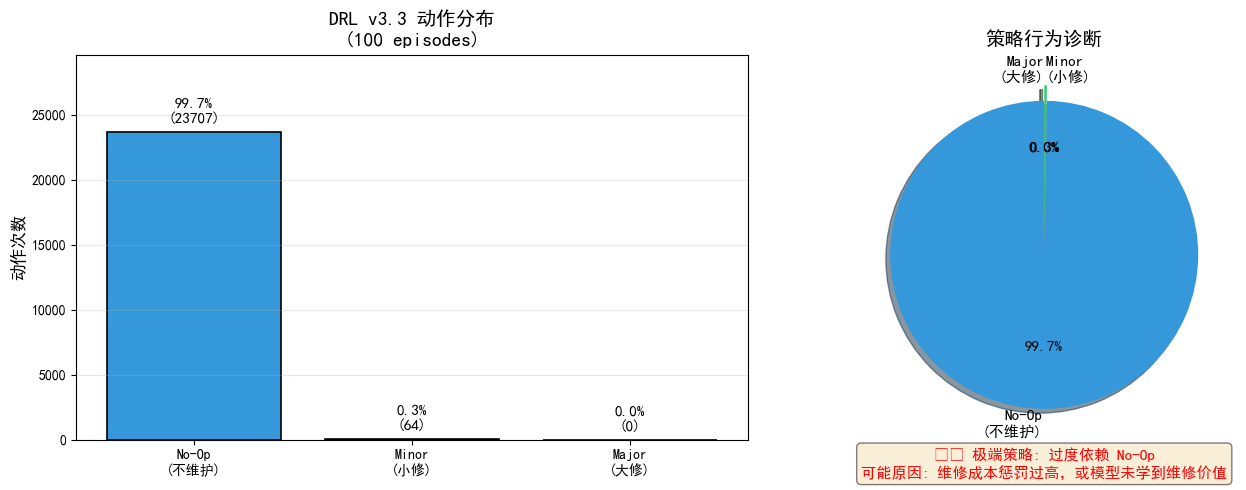


----------------------------------------
策略行为诊断:
----------------------------------------
  No-Op 占比: 99.7%
  Minor 占比: 0.3%
  Major 占比: 0.0%

  诊断结果: 极端 No-Op

✅ 动作分布分析完成，图表已保存至 drl_action_distribution.png


In [73]:
# ==========================================
# EVAL 3. 动作分布分析（策略行为可视化）
# ==========================================
"""
分析 DRL 策略的动作分布：
- 各动作的选择频率
- 检测是否存在极端策略（如 99% No-Op）
- 可视化对比
"""

print("=" * 70)
print("📊 动作分布分析")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# 图1: 动作频率柱状图
# ==========================================
ax1 = axes[0]

action_labels = ['No-Op\n(不维护)', 'Minor\n(小修)', 'Major\n(大修)']
action_counts = drl_results['action_total']
action_pcts = drl_results['action_pct']
colors = ['#3498db', '#2ecc71', '#e74c3c']

bars = ax1.bar(action_labels, action_counts, color=colors, edgecolor='black', linewidth=1.2)

# 在柱子上标注百分比
for bar, pct, count in zip(bars, action_pcts, action_counts):
    height = bar.get_height()
    ax1.annotate(f'{pct:.1f}%\n({count})',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylabel('动作次数', fontsize=12)
ax1.set_title(f'{model_name} 动作分布\n({N_EVAL_EPISODES} episodes)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(action_counts) * 1.25)
ax1.grid(axis='y', alpha=0.3)

# ==========================================
# 图2: 策略行为诊断饼图
# ==========================================
ax2 = axes[1]

# 检测极端策略
is_extreme_noop = action_pcts[0] > 90
is_extreme_major = action_pcts[2] > 70
is_balanced = 10 < action_pcts[0] < 70 and 10 < action_pcts[2] < 70

# 饼图
wedges, texts, autotexts = ax2.pie(
    action_counts, 
    labels=action_labels,
    autopct='%1.1f%%',
    colors=colors,
    explode=(0.05, 0.05, 0.05),
    shadow=True,
    startangle=90,
    textprops={'fontsize': 11}
)

# 策略诊断文本
if is_extreme_noop:
    diagnosis = "⚠️ 极端策略: 过度依赖 No-Op\n可能原因: 维修成本惩罚过高，或模型未学到维修价值"
    diagnosis_color = 'red'
elif is_extreme_major:
    diagnosis = "⚠️ 极端策略: 过度使用 Major Repair\n可能原因: 故障惩罚过高，模型过于保守"
    diagnosis_color = 'orange'
elif is_balanced:
    diagnosis = "✅ 策略相对均衡\n模型学会了在不同状态选择不同动作"
    diagnosis_color = 'green'
else:
    diagnosis = "ℹ️ 策略偏向特定动作\n建议: 检查奖励函数设计"
    diagnosis_color = 'blue'

ax2.set_title(f'策略行为诊断', fontsize=14, fontweight='bold')
ax2.text(0, -1.3, diagnosis, ha='center', va='top', fontsize=11, 
         color=diagnosis_color, wrap=True,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('drl_action_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印诊断信息
print("\n" + "-" * 40)
print("策略行为诊断:")
print("-" * 40)
print(f"  No-Op 占比: {action_pcts[0]:.1f}%")
print(f"  Minor 占比: {action_pcts[1]:.1f}%")
print(f"  Major 占比: {action_pcts[2]:.1f}%")
print(f"\n  诊断结果: {'极端 No-Op' if is_extreme_noop else '极端 Major' if is_extreme_major else '相对均衡' if is_balanced else '略有偏向'}")

print("\n✅ 动作分布分析完成，图表已保存至 drl_action_distribution.png")

📊 随时间的决策行为分析
收集 5 条测试轨迹...
  轨迹 1: Unit=390, Steps=218, Cost=2000.0, Term=end_of_trajectory
  轨迹 2: Unit=459, Steps=145, Cost=2000.0, Term=end_of_trajectory
  轨迹 3: Unit=388, Steps=200, Cost=2000.0, Term=end_of_trajectory
  轨迹 4: Unit=460, Steps=152, Cost=2000.0, Term=end_of_trajectory
  轨迹 5: Unit=135, Steps=196, Cost=2000.0, Term=end_of_trajectory


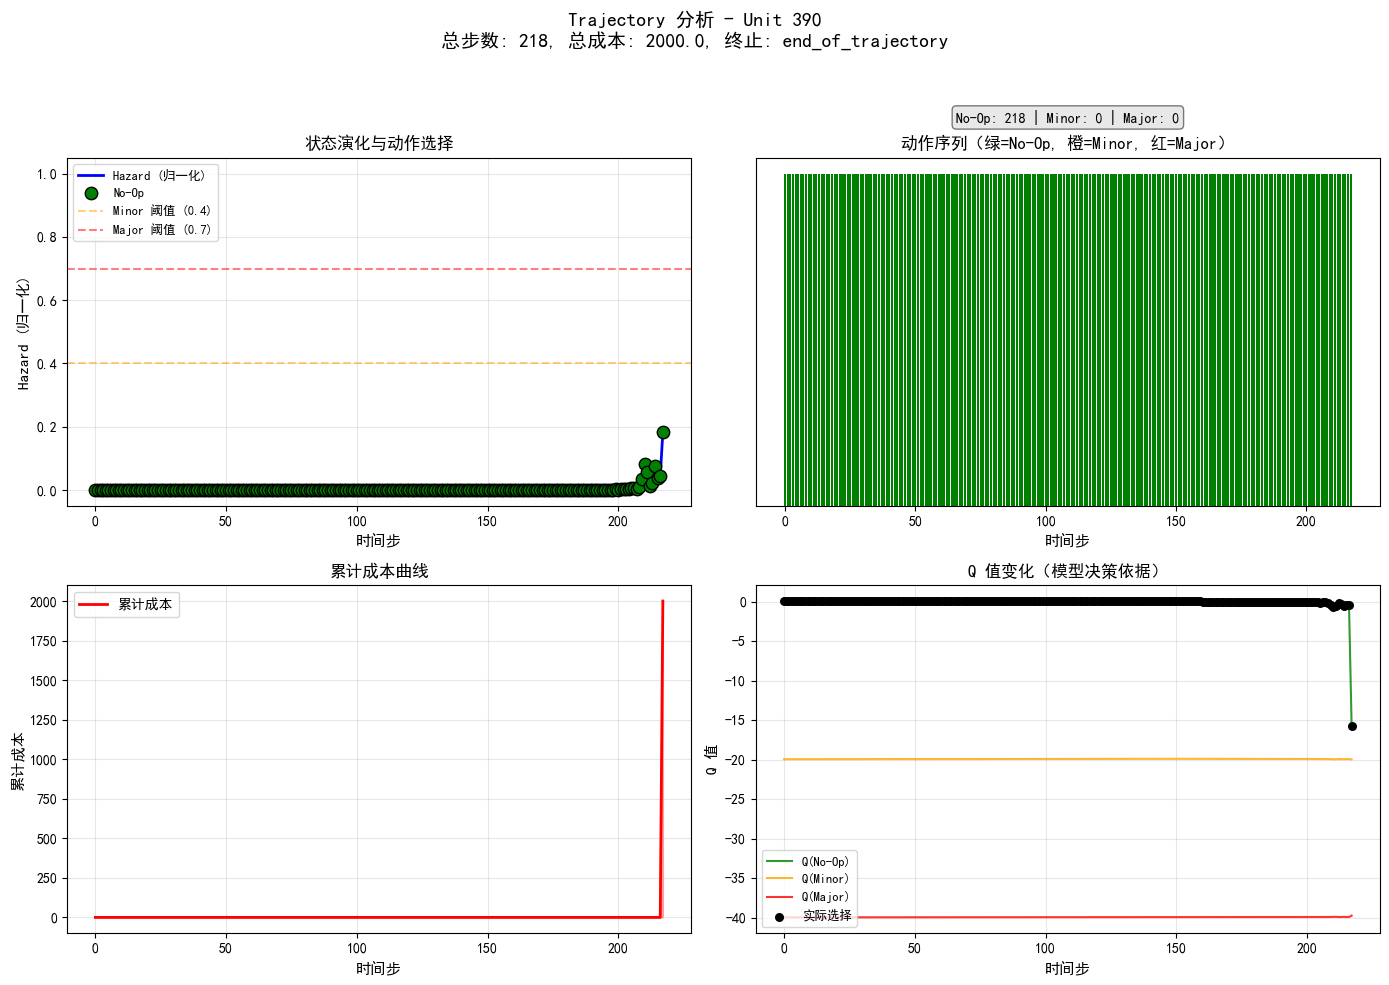

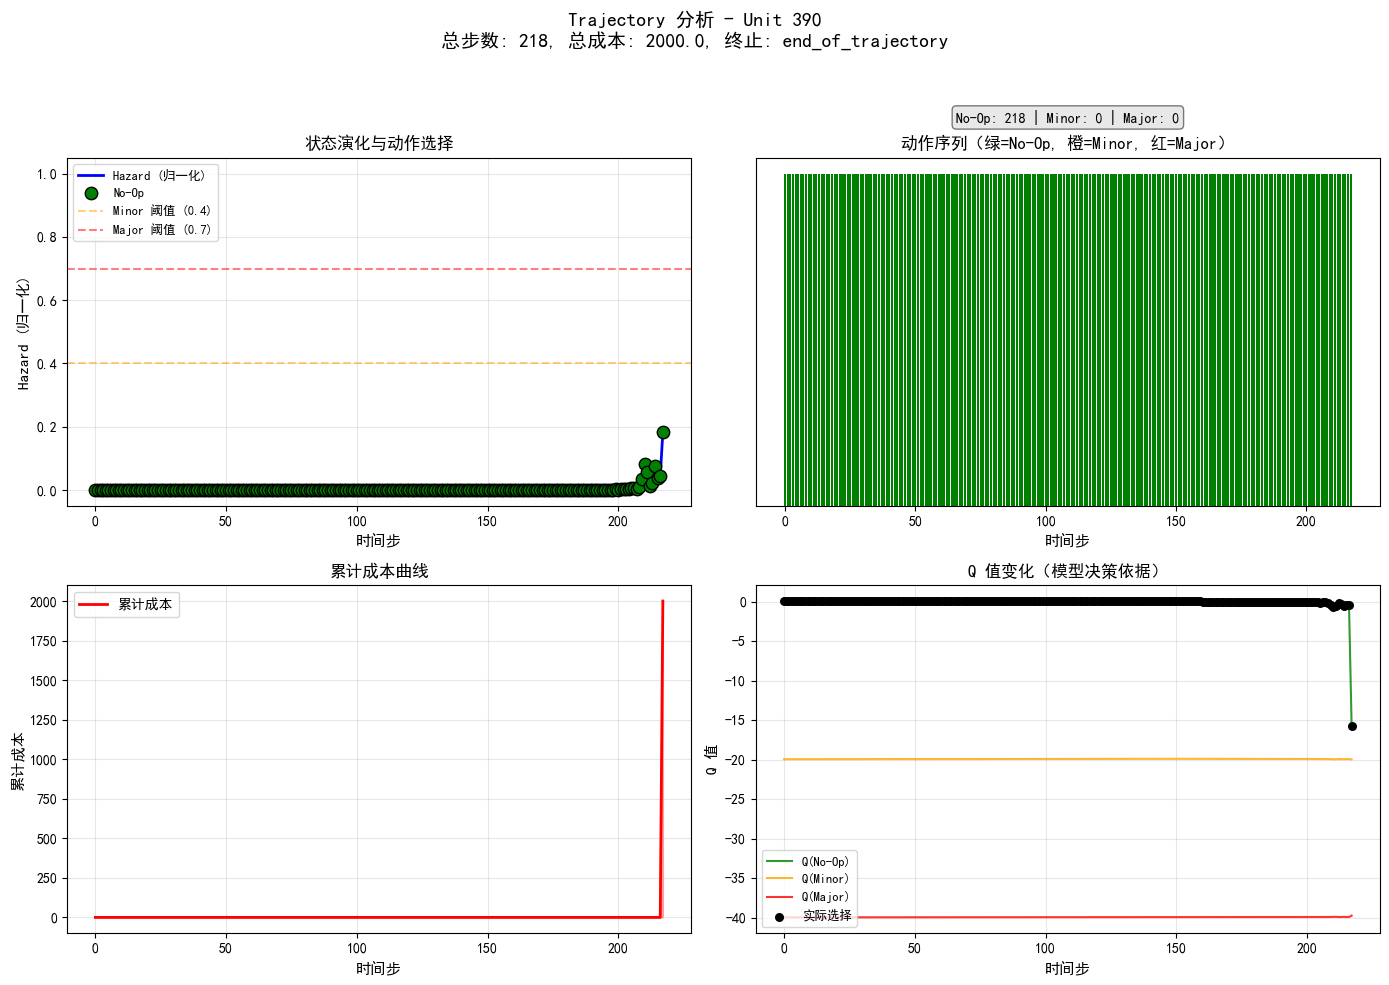


✅ Trajectory 分析完成！图表已保存


In [74]:
# ==========================================
# EVAL 4. 随时间的决策行为（Trajectory 可视化）
# ==========================================
"""
选取代表性 episode，可视化：
- 状态变化（hazard, age）
- 每步选择的动作
- 累计成本曲线
- Q 值变化

目的：让非技术人员"看得懂策略在干嘛"
"""

print("=" * 70)
print("📊 随时间的决策行为分析")
print("=" * 70)

# 收集多条轨迹，选择有代表性的
n_trajectories = 5
trajectories = []

print(f"收集 {n_trajectories} 条测试轨迹...")
for i in range(n_trajectories):
    unit_id = np.random.choice(test_units)
    traj = collect_trajectory(eval_model, env, unit_id=unit_id, deterministic=True)
    trajectories.append(traj)
    print(f"  轨迹 {i+1}: Unit={traj['unit_id']}, Steps={traj['total_steps']}, "
          f"Cost={traj['total_cost']:.1f}, Term={traj['termination']}")

# 选择两条代表性轨迹
# 1. 步数最长的（观察完整决策过程）
# 2. 有故障的（如果存在）
trajectories_sorted = sorted(trajectories, key=lambda x: x['total_steps'], reverse=True)
selected_trajs = [trajectories_sorted[0]]  # 最长的

# 找一条故障轨迹（如果有）
failure_trajs = [t for t in trajectories if t['termination'] != 'major_repair']
if failure_trajs:
    selected_trajs.append(failure_trajs[0])
elif len(trajectories_sorted) > 1:
    selected_trajs.append(trajectories_sorted[1])

# ==========================================
# 可视化每条轨迹
# ==========================================
for traj_idx, traj in enumerate(selected_trajs):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Trajectory 分析 - Unit {traj["unit_id"]}\n'
                 f'总步数: {traj["total_steps"]}, 总成本: {traj["total_cost"]:.1f}, '
                 f'终止: {traj["termination"]}',
                 fontsize=14, fontweight='bold')
    
    steps = np.arange(len(traj['actions']))
    
    # ===== 图1: Hazard 随时间变化 + 动作标记 =====
    ax1 = axes[0, 0]
    hazards = traj['hazard_norms'][:-1]  # 排除最后一个（动作后的状态）
    
    # 绘制 hazard 曲线
    ax1.plot(steps, hazards, 'b-', linewidth=2, label='Hazard (归一化)')
    
    # 用不同颜色标记动作
    action_colors = {0: 'green', 1: 'orange', 2: 'red'}
    action_markers = {0: 'o', 1: 's', 2: '^'}
    action_labels_plot = {0: 'No-Op', 1: 'Minor', 2: 'Major'}
    
    for a_type in [0, 1, 2]:
        mask = np.array(traj['actions']) == a_type
        if mask.any():
            ax1.scatter(steps[mask], np.array(hazards)[mask], 
                       c=action_colors[a_type], marker=action_markers[a_type],
                       s=80, label=action_labels_plot[a_type], zorder=5, edgecolors='black')
    
    # 阈值线
    ax1.axhline(y=0.4, color='orange', linestyle='--', alpha=0.5, label='Minor 阈值 (0.4)')
    ax1.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Major 阈值 (0.7)')
    
    ax1.set_xlabel('时间步', fontsize=11)
    ax1.set_ylabel('Hazard (归一化)', fontsize=11)
    ax1.set_title('状态演化与动作选择', fontsize=12)
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-0.05, 1.05)
    
    # ===== 图2: 动作序列（条形图）=====
    ax2 = axes[0, 1]
    action_seq = traj['actions']
    colors_seq = [action_colors[a] for a in action_seq]
    ax2.bar(steps, [1]*len(steps), color=colors_seq, edgecolor='none')
    ax2.set_yticks([])
    ax2.set_xlabel('时间步', fontsize=11)
    ax2.set_title('动作序列（绿=No-Op, 橙=Minor, 红=Major）', fontsize=12)
    
    # 添加动作统计
    action_counts_traj = [sum(1 for a in action_seq if a == i) for i in range(3)]
    stats_text = f"No-Op: {action_counts_traj[0]} | Minor: {action_counts_traj[1]} | Major: {action_counts_traj[2]}"
    ax2.text(0.5, 1.1, stats_text, transform=ax2.transAxes, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
    
    # ===== 图3: 累计成本曲线 =====
    ax3 = axes[1, 0]
    cumulative_costs = traj['cumulative_costs']
    ax3.plot(steps, cumulative_costs, 'r-', linewidth=2, label='累计成本')
    ax3.fill_between(steps, cumulative_costs, alpha=0.3, color='red')
    
    # 标记大修和故障点
    for i, a in enumerate(traj['actions']):
        if a == 2:  # Major repair
            ax3.axvline(x=i, color='red', linestyle=':', alpha=0.7)
            ax3.annotate('Major', (i, cumulative_costs[i]), textcoords="offset points",
                        xytext=(5, 10), fontsize=9, color='red')
    
    ax3.set_xlabel('时间步', fontsize=11)
    ax3.set_ylabel('累计成本', fontsize=11)
    ax3.set_title('累计成本曲线', fontsize=12)
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # ===== 图4: Q 值变化 =====
    ax4 = axes[1, 1]
    q_values = np.array(traj['q_values'])
    
    if len(q_values) > 0:
        ax4.plot(steps, q_values[:, 0], 'g-', linewidth=1.5, label='Q(No-Op)', alpha=0.8)
        ax4.plot(steps, q_values[:, 1], 'orange', linewidth=1.5, label='Q(Minor)', alpha=0.8)
        ax4.plot(steps, q_values[:, 2], 'r-', linewidth=1.5, label='Q(Major)', alpha=0.8)
        
        # 高亮实际选择的动作对应的 Q 值
        chosen_qs = [q_values[i, traj['actions'][i]] for i in range(len(traj['actions']))]
        ax4.scatter(steps, chosen_qs, c='black', s=30, zorder=5, label='实际选择')
    
    ax4.set_xlabel('时间步', fontsize=11)
    ax4.set_ylabel('Q 值', fontsize=11)
    ax4.set_title('Q 值变化（模型决策依据）', fontsize=12)
    ax4.legend(loc='best', fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f'drl_trajectory_unit_{traj["unit_id"]}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n✅ Trajectory 分析完成！图表已保存")

📊 稳定性与可行性分析


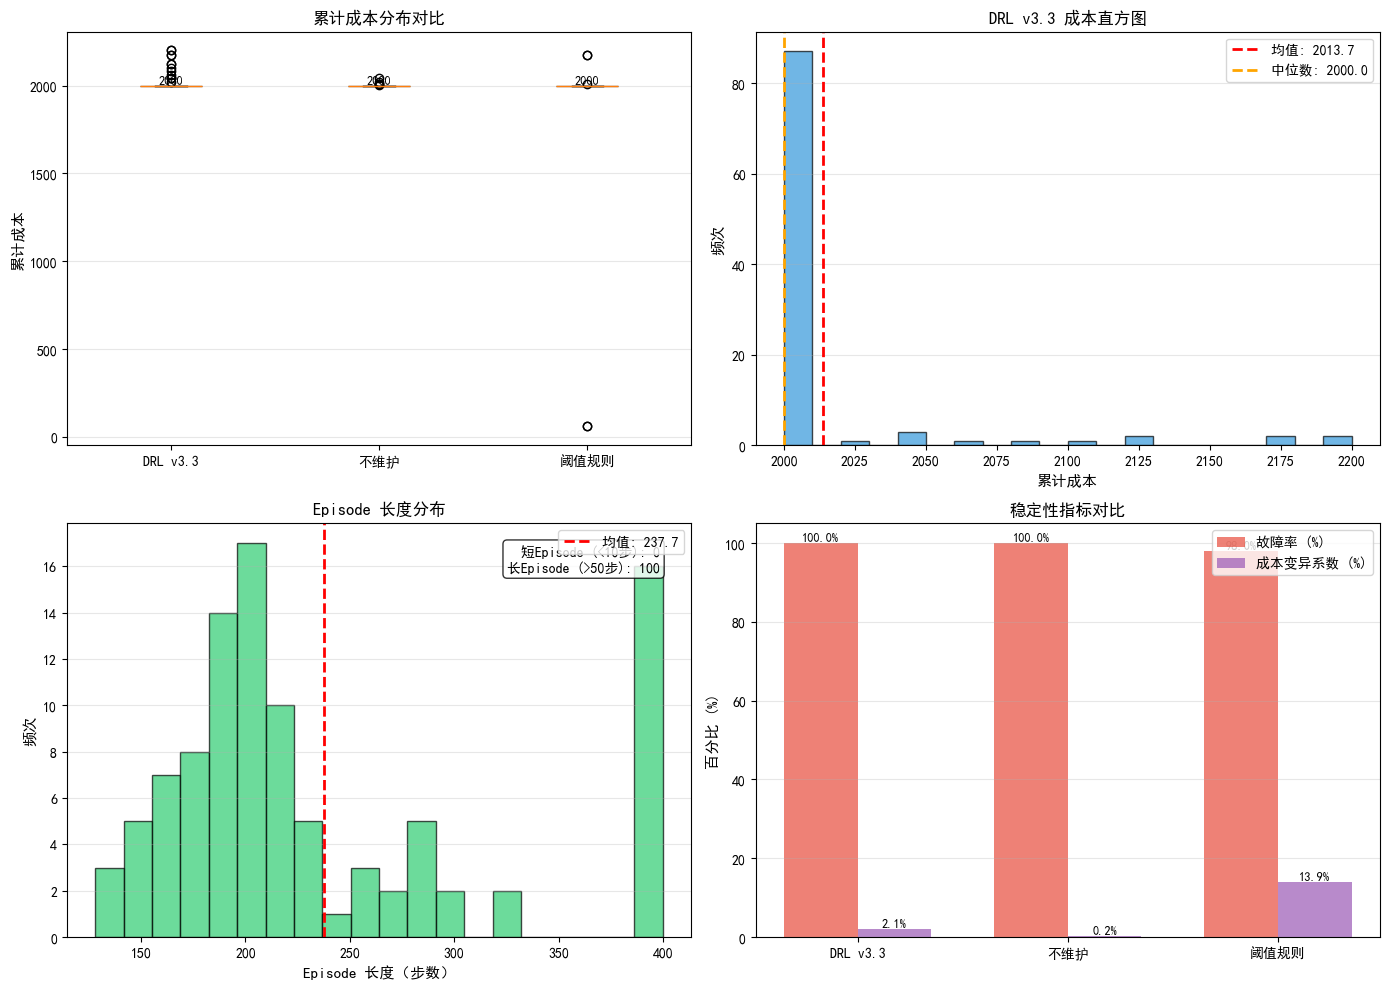


----------------------------------------
稳定性诊断:
----------------------------------------
  故障率: 100.0%
  成本变异系数: 2.1%
  最短 Episode: 128 步
  最长 Episode: 400 步

  综合评价: ⚠️ 高故障率 - DRL 策略未能有效避免故障

✅ 稳定性分析完成！图表已保存至 drl_stability_analysis.png


In [75]:
# ==========================================
# EVAL 5. 稳定性与可行性分析
# ==========================================
"""
分析 DRL 策略的稳定性：
- 累计成本的分布与波动
- Episode 长度分布（是否经常提前终止）
- 与基线策略的稳定性对比
"""

print("=" * 70)
print("📊 稳定性与可行性分析")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ==========================================
# 图1: 成本分布箱线图（多策略对比）
# ==========================================
ax1 = axes[0, 0]

cost_data = [
    drl_results['raw_costs'],
    no_maint_results['raw_costs'],
    threshold_results['raw_costs']
]
labels = [model_name, '不维护', '阈值规则']
colors_box = ['#3498db', '#e74c3c', '#2ecc71']

bp = ax1.boxplot(cost_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax1.set_ylabel('累计成本', fontsize=11)
ax1.set_title('累计成本分布对比', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 添加统计信息
for i, (data, label) in enumerate(zip(cost_data, labels)):
    median = np.median(data)
    ax1.text(i+1, median, f'{median:.0f}', ha='center', va='bottom', fontsize=9)

# ==========================================
# 图2: 成本直方图（DRL）
# ==========================================
ax2 = axes[0, 1]

ax2.hist(drl_results['raw_costs'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
ax2.axvline(drl_results['cost_mean'], color='red', linestyle='--', linewidth=2, label=f'均值: {drl_results["cost_mean"]:.1f}')
ax2.axvline(drl_results['cost_median'], color='orange', linestyle='--', linewidth=2, label=f'中位数: {drl_results["cost_median"]:.1f}')

ax2.set_xlabel('累计成本', fontsize=11)
ax2.set_ylabel('频次', fontsize=11)
ax2.set_title(f'{model_name} 成本直方图', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# ==========================================
# 图3: Episode 长度分布
# ==========================================
ax3 = axes[1, 0]

ax3.hist(drl_results['raw_steps'], bins=20, color='#2ecc71', edgecolor='black', alpha=0.7)
ax3.axvline(drl_results['steps_mean'], color='red', linestyle='--', linewidth=2, 
            label=f'均值: {drl_results["steps_mean"]:.1f}')

ax3.set_xlabel('Episode 长度（步数）', fontsize=11)
ax3.set_ylabel('频次', fontsize=11)
ax3.set_title('Episode 长度分布', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 检测是否有大量提前终止
short_episodes = sum(1 for s in drl_results['raw_steps'] if s < 10)
long_episodes = sum(1 for s in drl_results['raw_steps'] if s > 50)
ax3.text(0.95, 0.95, f'短Episode (<10步): {short_episodes}\n长Episode (>50步): {long_episodes}',
         transform=ax3.transAxes, ha='right', va='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ==========================================
# 图4: 故障率与成本变异系数对比
# ==========================================
ax4 = axes[1, 1]

# 计算变异系数（CV = std / mean）
cv_drl = drl_results['cost_std'] / drl_results['cost_mean'] * 100 if drl_results['cost_mean'] > 0 else 0
cv_no_maint = no_maint_results['cost_std'] / no_maint_results['cost_mean'] * 100 if no_maint_results['cost_mean'] > 0 else 0
cv_threshold = threshold_results['cost_std'] / threshold_results['cost_mean'] * 100 if threshold_results['cost_mean'] > 0 else 0

x_pos = np.arange(3)
width = 0.35

# 故障率
failure_rates = [drl_results['failure_rate']*100, no_maint_results['failure_rate']*100, threshold_results['failure_rate']*100]
bars1 = ax4.bar(x_pos - width/2, failure_rates, width, label='故障率 (%)', color='#e74c3c', alpha=0.7)

# 变异系数
cvs = [cv_drl, cv_no_maint, cv_threshold]
bars2 = ax4.bar(x_pos + width/2, cvs, width, label='成本变异系数 (%)', color='#9b59b6', alpha=0.7)

ax4.set_xticks(x_pos)
ax4.set_xticklabels(labels)
ax4.set_ylabel('百分比 (%)', fontsize=11)
ax4.set_title('稳定性指标对比', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# 标注数值
for bar, val in zip(bars1, failure_rates):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.1f}%',
             ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, cvs):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.1f}%',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('drl_stability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 打印稳定性诊断
# ==========================================
print("\n" + "-" * 40)
print("稳定性诊断:")
print("-" * 40)
print(f"  故障率: {drl_results['failure_rate']*100:.1f}%")
print(f"  成本变异系数: {cv_drl:.1f}%")
print(f"  最短 Episode: {drl_results['steps_min']} 步")
print(f"  最长 Episode: {drl_results['steps_max']} 步")

# 稳定性评价
if drl_results['failure_rate'] > 0.5:
    stability_msg = "⚠️ 高故障率 - DRL 策略未能有效避免故障"
elif cv_drl > 100:
    stability_msg = "⚠️ 高成本波动 - DRL 策略不稳定"
elif drl_results['failure_rate'] < 0.2 and cv_drl < 50:
    stability_msg = "✅ 策略相对稳定 - 故障率低，成本波动可控"
else:
    stability_msg = "ℹ️ 策略稳定性一般 - 建议进一步调优"

print(f"\n  综合评价: {stability_msg}")

print("\n✅ 稳定性分析完成！图表已保存至 drl_stability_analysis.png")

## 📋 评估结果汇总（可直接用于 PPT）

### 1. DRL 整体评估汇总表

下表展示了 DRL 策略与基线策略在 100 个测试 episode 上的表现对比。

| 指标 | DRL 策略 | 始终不维护 | 阈值规则 |
|:----:|:--------:|:----------:|:--------:|
| 平均成本 | 见下方输出 | 见下方输出 | 见下方输出 |
| 成本标准差 | 见下方输出 | 见下方输出 | 见下方输出 |
| 故障率 | 见下方输出 | 100% | 见下方输出 |

### 2. 关键发现与解读

运行下方代码生成最终汇总。

📋 DRL 评估最终汇总（PPT Ready）

### 📊 评估汇总表 (可复制到 PPT)

| 指标 | DRL v3.3 | 始终不维护 | 阈值规则 |
|:-----|:-------:|:----------:|:--------:|
| 平均成本 | 2013.7 | 2000.8 | 1964.8 |
| 成本标准差 | 42.0 | 4.6 | 273.2 |
| 最小成本 | 2000.0 | 2000.0 | 60.0 |
| 最大成本 | 2200.0 | 2040.0 | 2175.0 |
| 平均步数 | 237.7 | 231.7 | 222.0 |
| 故障率 | 100.0% | 100.0% | 98.0% |

### 📊 DRL 动作分布

| 动作 | 次数 | 占比 |
|:-----|:----:|:----:|
| No-Op (不维护) | 23707 | 99.7% |
| Minor (小修) | 64 | 0.3% |
| Major (大修) | 0 | 0.0% |

🔍 关键发现与解读

【1. 成本效果】
  ⚠️ vs 不维护: 成本增加 0.6%
  ⚠️ vs 阈值规则: 成本增加 2.5%

【2. 策略行为】
  ⚠️ 极端 No-Op 策略: 99.7% 的时间选择不维护
     → 可能原因: 维修成本惩罚过高，模型未学到预防维护的价值
     → 与论文差异: 论文中 Minor/Major 比例应更高

【3. 稳定性】
  故障率: 100.0%
  成本变异系数: 2.1%
  ⚠️ 高故障率说明 DRL 未能有效学习预防维护策略

【4. 与论文设定的差异（已知）】
  - 状态定义: 使用 (hazard_norm, age_norm) 二维状态
  - 奖励函数: 包含故障惩罚 C_fail=2000.0
  - 小修效果: R0=0.3, ETA0=0.25, DECAY=0.15
  - 这些参数与原论文可能存在差异，是导致结果不同的主要原因

🏆 综合评价

  评级: C - 及格
  得分: 25/100
  评语: DRL 策略效果有限，需要调整参数或奖励函数

📊 生成一图总览...


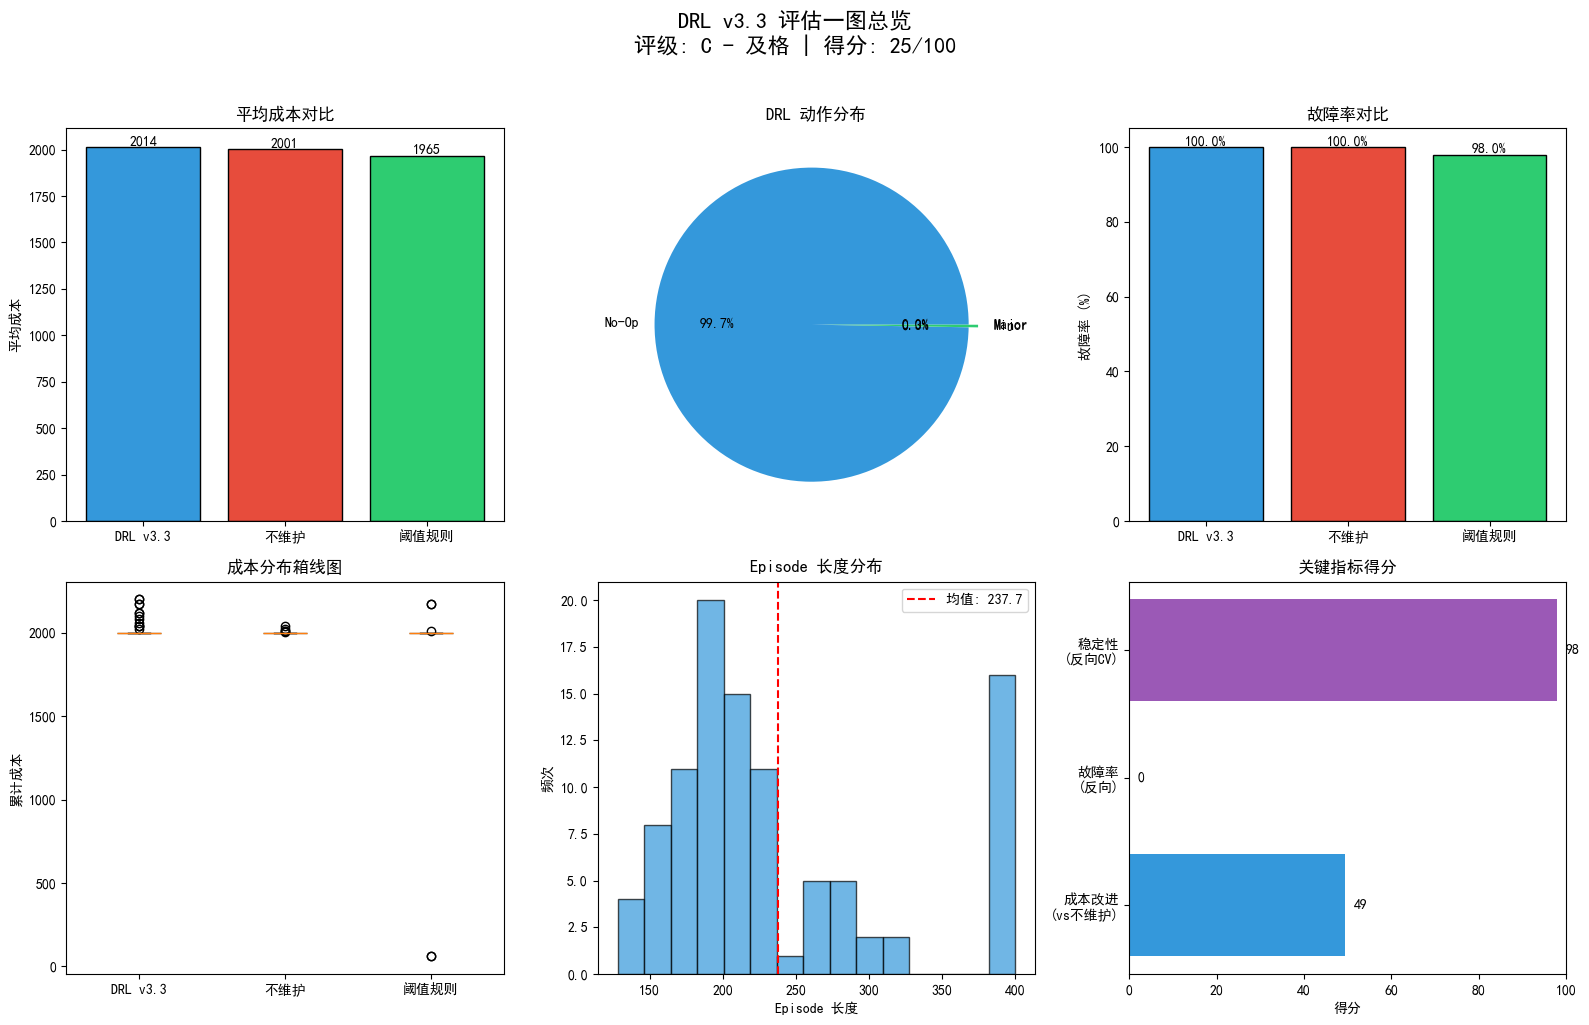


✅ 一图总览已保存至 drl_evaluation_summary.png

🎉 DRL 评估完成！

生成的文件:
  📊 drl_action_distribution.png - 动作分布图
  📊 drl_trajectory_unit_*.png   - 轨迹分析图
  📊 drl_stability_analysis.png  - 稳定性分析图
  📊 drl_evaluation_summary.png  - 一图总览


In [76]:
# ==========================================
# EVAL 6. 最终汇总与 PPT 输出
# ==========================================
"""
生成可直接用于 PPT 的汇总表格和关键图表
"""

print("=" * 70)
print("📋 DRL 评估最终汇总（PPT Ready）")
print("=" * 70)

# ==========================================
# 汇总表格（Markdown 格式）
# ==========================================
print("\n### 📊 评估汇总表 (可复制到 PPT)")
print()
print("| 指标 | {} | 始终不维护 | 阈值规则 |".format(model_name))
print("|:-----|:-------:|:----------:|:--------:|")
print("| 平均成本 | {:.1f} | {:.1f} | {:.1f} |".format(
    drl_results['cost_mean'], no_maint_results['cost_mean'], threshold_results['cost_mean']))
print("| 成本标准差 | {:.1f} | {:.1f} | {:.1f} |".format(
    drl_results['cost_std'], no_maint_results['cost_std'], threshold_results['cost_std']))
print("| 最小成本 | {:.1f} | {:.1f} | {:.1f} |".format(
    drl_results['cost_min'], np.min(no_maint_results['raw_costs']), np.min(threshold_results['raw_costs'])))
print("| 最大成本 | {:.1f} | {:.1f} | {:.1f} |".format(
    drl_results['cost_max'], np.max(no_maint_results['raw_costs']), np.max(threshold_results['raw_costs'])))
print("| 平均步数 | {:.1f} | {:.1f} | {:.1f} |".format(
    drl_results['steps_mean'], no_maint_results['steps_mean'], threshold_results['steps_mean']))
print("| 故障率 | {:.1f}% | {:.1f}% | {:.1f}% |".format(
    drl_results['failure_rate']*100, no_maint_results['failure_rate']*100, threshold_results['failure_rate']*100))

# ==========================================
# 动作分布汇总
# ==========================================
print("\n### 📊 DRL 动作分布")
print()
print("| 动作 | 次数 | 占比 |")
print("|:-----|:----:|:----:|")
print("| No-Op (不维护) | {} | {:.1f}% |".format(
    int(drl_results['action_total'][0]), drl_results['action_pct'][0]))
print("| Minor (小修) | {} | {:.1f}% |".format(
    int(drl_results['action_total'][1]), drl_results['action_pct'][1]))
print("| Major (大修) | {} | {:.1f}% |".format(
    int(drl_results['action_total'][2]), drl_results['action_pct'][2]))

# ==========================================
# 关键发现
# ==========================================
print("\n" + "=" * 70)
print("🔍 关键发现与解读")
print("=" * 70)

# 1. 成本效果分析
improvement_no_maint = (no_maint_results['cost_mean'] - drl_results['cost_mean']) / no_maint_results['cost_mean'] * 100
improvement_threshold = (threshold_results['cost_mean'] - drl_results['cost_mean']) / threshold_results['cost_mean'] * 100

print("\n【1. 成本效果】")
if improvement_no_maint > 0:
    print(f"  ✅ vs 不维护: 成本降低 {improvement_no_maint:.1f}%")
else:
    print(f"  ⚠️ vs 不维护: 成本增加 {-improvement_no_maint:.1f}%")

if improvement_threshold > 0:
    print(f"  ✅ vs 阈值规则: 成本降低 {improvement_threshold:.1f}%")
else:
    print(f"  ⚠️ vs 阈值规则: 成本增加 {-improvement_threshold:.1f}%")

# 2. 策略行为分析
print("\n【2. 策略行为】")
noop_pct = drl_results['action_pct'][0]
minor_pct = drl_results['action_pct'][1]
major_pct = drl_results['action_pct'][2]

if noop_pct > 90:
    print(f"  ⚠️ 极端 No-Op 策略: {noop_pct:.1f}% 的时间选择不维护")
    print(f"     → 可能原因: 维修成本惩罚过高，模型未学到预防维护的价值")
    print(f"     → 与论文差异: 论文中 Minor/Major 比例应更高")
elif major_pct > 70:
    print(f"  ⚠️ 过度大修策略: {major_pct:.1f}% 的时间选择 Major Repair")
    print(f"     → 可能原因: 故障惩罚过高，模型过于保守")
else:
    print(f"  ✅ 策略相对均衡")
    print(f"     → No-Op: {noop_pct:.1f}%, Minor: {minor_pct:.1f}%, Major: {major_pct:.1f}%")

# 3. 稳定性分析
print("\n【3. 稳定性】")
cv = drl_results['cost_std'] / drl_results['cost_mean'] * 100 if drl_results['cost_mean'] > 0 else 0
failure_rate = drl_results['failure_rate'] * 100

print(f"  故障率: {failure_rate:.1f}%")
print(f"  成本变异系数: {cv:.1f}%")

if failure_rate > 50:
    print(f"  ⚠️ 高故障率说明 DRL 未能有效学习预防维护策略")
elif cv > 100:
    print(f"  ⚠️ 高成本波动说明策略不稳定")
else:
    print(f"  ✅ 策略稳定性在可接受范围内")

# 4. 与论文设定的差异说明
print("\n【4. 与论文设定的差异（已知）】")
print(f"  - 状态定义: 使用 (hazard_norm, age_norm) 二维状态")
print(f"  - 奖励函数: 包含故障惩罚 C_fail={C_FAIL_FIXED}")
print(f"  - 小修效果: R0={R0}, ETA0={ETA0}, DECAY={DECAY}")
print(f"  - 这些参数与原论文可能存在差异，是导致结果不同的主要原因")

# ==========================================
# 综合评价
# ==========================================
print("\n" + "=" * 70)
print("🏆 综合评价")
print("=" * 70)

# 打分
score = 0
if improvement_no_maint > 0: score += 25
if improvement_threshold > 0: score += 25
if failure_rate < 30: score += 25
if cv < 80: score += 25

if score >= 75:
    grade = "A - 优秀"
    comment = "DRL 策略在当前设定下表现良好，可用于实际决策参考"
elif score >= 50:
    grade = "B - 良好"
    comment = "DRL 策略有一定效果，但存在改进空间"
elif score >= 25:
    grade = "C - 及格"
    comment = "DRL 策略效果有限，需要调整参数或奖励函数"
else:
    grade = "D - 需改进"
    comment = "DRL 策略在当前设定下表现不佳，建议重新设计"

print(f"\n  评级: {grade}")
print(f"  得分: {score}/100")
print(f"  评语: {comment}")

# ==========================================
# 生成一图总览
# ==========================================
print("\n" + "=" * 70)
print("📊 生成一图总览...")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f'{model_name} 评估一图总览\n评级: {grade} | 得分: {score}/100', 
             fontsize=16, fontweight='bold', y=1.02)

# 图1: 成本对比柱状图
ax1 = axes[0, 0]
strategies = [model_name, '不维护', '阈值规则']
costs = [drl_results['cost_mean'], no_maint_results['cost_mean'], threshold_results['cost_mean']]
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax1.bar(strategies, costs, color=colors, edgecolor='black')
ax1.set_ylabel('平均成本')
ax1.set_title('平均成本对比')
for bar, cost in zip(bars, costs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{cost:.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 图2: 动作分布饼图
ax2 = axes[0, 1]
action_labels = ['No-Op', 'Minor', 'Major']
action_colors = ['#3498db', '#2ecc71', '#e74c3c']
ax2.pie(drl_results['action_total'], labels=action_labels, autopct='%1.1f%%',
        colors=action_colors, explode=(0.03, 0.03, 0.03))
ax2.set_title('DRL 动作分布')

# 图3: 故障率对比
ax3 = axes[0, 2]
failure_rates = [drl_results['failure_rate']*100, no_maint_results['failure_rate']*100, 
                 threshold_results['failure_rate']*100]
bars = ax3.bar(strategies, failure_rates, color=colors, edgecolor='black')
ax3.set_ylabel('故障率 (%)')
ax3.set_title('故障率对比')
for bar, rate in zip(bars, failure_rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{rate:.1f}%',
             ha='center', va='bottom', fontsize=10)

# 图4: 成本箱线图
ax4 = axes[1, 0]
bp = ax4.boxplot([drl_results['raw_costs'], no_maint_results['raw_costs'], threshold_results['raw_costs']],
                  labels=strategies, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax4.set_ylabel('累计成本')
ax4.set_title('成本分布箱线图')

# 图5: Episode 长度直方图
ax5 = axes[1, 1]
ax5.hist(drl_results['raw_steps'], bins=15, color='#3498db', edgecolor='black', alpha=0.7)
ax5.axvline(drl_results['steps_mean'], color='red', linestyle='--', label=f'均值: {drl_results["steps_mean"]:.1f}')
ax5.set_xlabel('Episode 长度')
ax5.set_ylabel('频次')
ax5.set_title('Episode 长度分布')
ax5.legend()

# 图6: 关键指标雷达图（简化为条形图）
ax6 = axes[1, 2]
metrics = ['成本改进\n(vs不维护)', '故障率\n(反向)', '稳定性\n(反向CV)']
# 归一化到 0-100
cost_score = max(0, min(100, improvement_no_maint + 50))  # 改进50%=100分
failure_score = max(0, 100 - failure_rate)  # 0%故障=100分
stability_score = max(0, 100 - cv)  # CV=0=100分
scores = [cost_score, failure_score, stability_score]
ax6.barh(metrics, scores, color=['#3498db', '#2ecc71', '#9b59b6'])
ax6.set_xlim(0, 100)
ax6.set_xlabel('得分')
ax6.set_title('关键指标得分')
for i, s in enumerate(scores):
    ax6.text(s + 2, i, f'{s:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('drl_evaluation_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ 一图总览已保存至 drl_evaluation_summary.png")
print("\n" + "=" * 70)
print("🎉 DRL 评估完成！")
print("=" * 70)
print("\n生成的文件:")
print("  📊 drl_action_distribution.png - 动作分布图")
print("  📊 drl_trajectory_unit_*.png   - 轨迹分析图")
print("  📊 drl_stability_analysis.png  - 稳定性分析图")
print("  📊 drl_evaluation_summary.png  - 一图总览")

---

## 📝 图表解读说明（PPT 用）

### 图1: 动作分布图 (`drl_action_distribution.png`)

**这张图说明了什么：**
- 展示 DRL 策略在测试过程中选择各动作的频率
- 反映模型是否学会了"在正确时机选择正确动作"

**可能暴露的问题：**
- 如果 No-Op 占比 >90%：模型可能陷入"消极策略"，未能学习预防维护的价值
- 如果 Major 占比 >70%：模型可能过于保守，倾向于"能大修就大修"
- 均衡的分布（如 No-Op 40-60%, Minor 20-30%, Major 20-30%）表明模型学会了情境决策

**与论文设定可能差异的原因：**
- 奖励函数设计（故障惩罚 C_fail 的大小）
- 状态表示方式（本实现使用 2 维连续状态）
- 小修效果参数（R0, ETA0, DECAY）

---

### 图2: Trajectory 分析图 (`drl_trajectory_unit_*.png`)

**这张图说明了什么：**
- 展示单个 episode 中，模型如何根据状态变化做出决策
- 可视化 hazard 随时间变化、动作选择时机、累计成本增长

**可能暴露的问题：**
- 如果在高 hazard 时选择 No-Op：模型可能未正确感知风险
- 如果 Q 值曲线平坦：模型可能未区分不同状态的价值差异
- 如果累计成本在最后突增：模型未能有效避免故障

**阅读要点：**
- 红色标记（Major）应出现在 hazard 较高时
- 橙色标记（Minor）应在中等 hazard 时
- 绿色标记（No-Op）应在低 hazard 时

---

### 图3: 稳定性分析图 (`drl_stability_analysis.png`)

**这张图说明了什么：**
- 成本分布：DRL 策略的成本是否稳定、可预测
- Episode 长度：模型是否经常触发提前终止（大修/故障）
- 故障率与变异系数：衡量策略可靠性

**可能暴露的问题：**
- 高变异系数（>100%）：策略不稳定，难以预测
- 高故障率（>50%）：策略未能有效避免故障
- Episode 长度过短：可能过度使用 Major Repair

---

### 图4: 一图总览 (`drl_evaluation_summary.png`)

**适合放在 PPT 总结页，一目了然展示：**
- 成本对比：DRL vs 基线
- 动作分布：策略行为
- 故障率：安全性
- 成本分布：稳定性
- 关键指标得分：综合评价